# Deep Learning

### This project is for some exercise of deep learning


# The wall of imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from sklearn.model_selection import train_test_split
import torch
import torchvision
from torchvision import transforms, utils, datasets
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter
from PIL import Image
from skimage import io, transform
import os
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from collections import Counter
from google.colab import drive
import time

## Set up GPU capabilities

The cell below sets up a CUDA device to use with torch, if available to you.

**Remember to turn on the GPU for runtime in Colab**
*   Go to Runtime -> Change runtime type --> GPU

Note that you can create a PyTorch tensor `T` that resides on the GPU using the command `T = torch.Tensor(..., device=cuda)`.
You can also copy existing tensors to the GPU with the command `T = T.to(device)` (make sure to overwrite `T` with the result of this function call). If you do not have a GPU, these commands will still work.

In [ ]:
# DO NOT MODIFY
torch.manual_seed(42) # For consistency
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(torch.__version__)
print(device)

2.9.0+cu126
cuda:0


In [ ]:
device

device(type='cuda', index=0)

# Main Section: Image Classification with Traditional Deep Learning Techniques
In this first part, we will deploy neural networks to classify images. This section will provide a fundamental overview of building deep learning models with PyTorch, and the techniques you learn here can be applied to any type of model you may build in the future. Additionally, this section can serve as a primer for the supplementary section on convolutional neural networks, which are a much more powerful algorithm for performing image classification.

We'll start by loading in our data and performing preprocessing and exploratory data analysis (EDA) before attempting to perform image classification by implementing two different classifier models: Logistic Regression and Fully Connected Networks.

If you run into any troubles while working on this homework assignment, it is highly recommended that you consult the PyTorch documentation (https://docs.pytorch.org/docs/stable/index.html). Please also make sure that you have selected the correct runtime type for when you train the models. Consult the instructions at the beginning of this notebook if you have any issues there.



##Part 1. Data Preprocessing and Preparation for Modeling in PyTorch

###1.1: Data Loading

To keep data loading consistent across different models, PyTorch provides two data primitives: `torch.utils.data.DataLoader` and `torch.utils.data.Dataset` that allow you to use pre-loaded datasets as well as your own data.

`Dataset` stores the samples and their corresponding labels. And `DataLoader` wraps an iterable around the Dataset to enable easy access to the samples.

While Pytorch provides Dataset and Dataloader for some popular datasets, most of the time we need to define our own Custom Dataset to process our dataset.

In this case, we will be working with pre-defined datasets in PyTorch. In particular, we will be working with the Fashion-MNIST dataset, which is a dataset of 70,000 grayscale images of 10 different types of clothing and accessories. The images are 28x28 pixels, and there are 10 classes of images: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot.

To learn more about the dataset, check out this [paper](https://arxiv.org/abs/1708.07747), and visit the PyTorch documentation [here](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).

(there is no coding for 1.1, continue with 1.1.1)

####1.1.1 Preprocessing

A critical aspect of image machine learning in PyTorch is image preprocessing. This greatly improves standardization amongst images and therefore improves model accuracy.

**TODO:** In the cell below, define `transform` as a PyTorch `transforms.Compose` object with the following preprocessing transformations:
* Convert images to tensors.
* Normalize the pixel values (mean=0.5, std=0.5), which ensures all pixel values are in the range of [-1, 1] and will thus have an equal influence to the model.
* Flatten the 28x28 image into a 784-element vector.

We encourage you to view the [PyTorch Documentation](https://pytorch.org/vision/stable/transforms.html) for this section.




In [ ]:
# TODO: Define PyTorch Transform Object
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, ), (0.5, ), transforms.Lambda(lambda x: x.view(-1)))])

#### 1.1.2: Load Dataset

Now that we have defined our transform object, the next step is to import the Fashion-MNIST dataset using PyTorch.

**TODO:** Define `train_dataset` and `test_dataset` as the training and test data in the Fashion-MNIST dataset in the cell below. Be sure to use the transform defined in the previous section.

**Note:** Although we are defining these as dataset objects, please note that they should be imported from Torchvision. For more information, please visit the PyTorch documentation.

In [ ]:
# TODO: Load datasets
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train = True, download = True, transform = transform)

test_dataset =torchvision.datasets.FashionMNIST(root='./data', train = False, download = True, transform = transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 189kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.53MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.5MB/s]


#### 1.1.3: Create `DataLoader` Objects

Finally, to allow for easy loading into our machine learning model, PyTorch has defined the `DataLoader` class, which allows us to directly iterate through our data in our model training and testing.

**TODO:** Create `train_loader` and `test_loader` based off of the training and test sets, respectively. Please adhere to the following parameters:
* `batch_size = 64`
* `shuffle = True`
* `num_workers = 0`

For more information on the `DataLoader` class, we encourage you to visit the [PyTorch documentation](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [ ]:
# TODO: Define DataLoaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True, num_workers = 0)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 64, shuffle = False, num_workers = 0)

### 1.2: EDA on our Dataset

To better understand our dataset, we will perform some EDA on our images.

**TODO:** In the below cell, we will visualize one image from each of 10 labels in the Fashion-MNIST dataset. Please create a plot with the following properties:
* 10 images, each of which corresponds to the 10 unique labels in the dataset.
* Each image should include a caption with its class name, not the numeric label (ex. Sandal). Double-check your captions after plotting.
* Use `plt.subplots()` to generate a figure with 2 rows/5 columns.
* Remove tick marks and x/y labels for each image.
* Note that you will have to reshape the image from a 784 element vector back to a 28x28 object.

Hint: Pull data from the first batch of the training data.

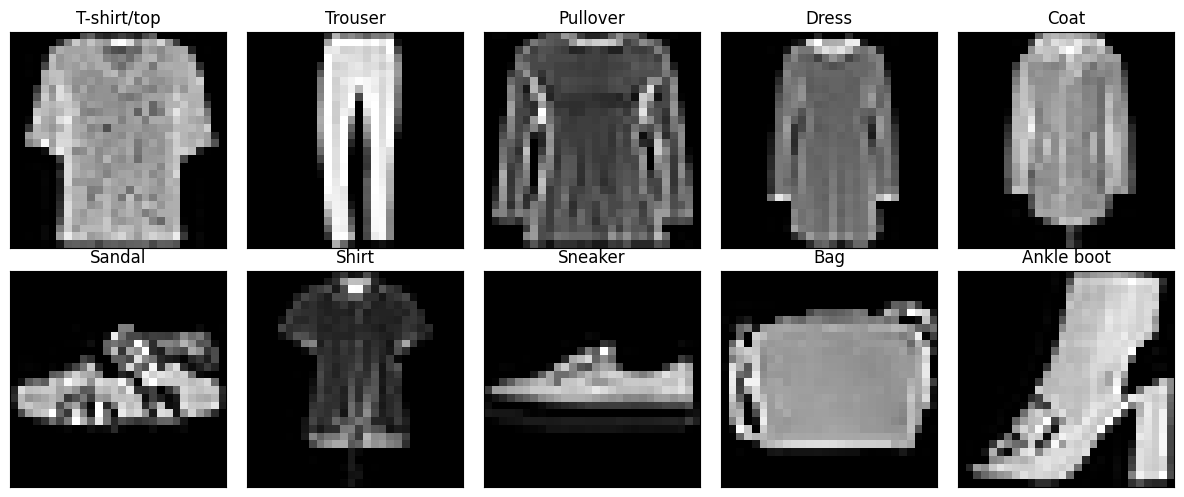

In [ ]:
# TODO: Perform EDA

# Get data of each label from the first batch of training data
classes = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker',
           8: 'Bag', 9: 'Ankle boot'}
images, labels = next(iter(train_loader))
unique_images = {}
for i in range(len(labels)):
  label_num = labels[i].item()
  if label_num not in unique_images:
    unique_images[label_num] = images[i]
  if len(unique_images) == 10:
    break

# Plot images
fig, axes = plt.subplots(nrows = 2, ncols = 5, figsize = (12, 5))
axes = axes.flatten()
sorted_items = sorted(unique_images.items())
# Generate figure
for i, (label_num, image_tensor) in enumerate(sorted_items):
    img = image_tensor.numpy().reshape(28, 28)

    # Plot the image on the corresponding axis
    axes[i].imshow(img, cmap = 'gray')

    # Set the caption (class name)
    axes[i].set_title(classes[label_num])

    # Remove tick marks and x/y labels
    axes[i].set_xticks([])
    axes[i].set_yticks([])

# Adjust layout to prevent titles from overlapping
plt.tight_layout()
plt.show()
# Create dictionary of labels


From your final figure, you should be able to see that there have been some distortions due to the transforms that have already been applied to the dataset.

## **Part 2:** Logistic Regression in PyTorch
We will first attempt to perform classification using a Logistic Regression classifier. In Logistic Regression, we attempt to model the probabilities of images belonging to different classes. Specifically, logistic regression can be expressed as:

$\text{log}\frac{p(X)}{1-p(X)}= \beta_0+\beta_1X$

The left hand side of this equation is called the **logit** or log-odds function. The odds signify the ratio of probability of success (correct classification) to probability of failure (incorrect classification), represented by a linear combination of inputs. In machine learning, we often use *link functions* to map linear scores (like log-odds) to probabilities. In logistic regression, the link function is the **sigmoid** function, which transforms the linear log-odds score into a probability between 0 and 1. The sigmoid function is:

$\sigma(z)=\frac{1}{1+e^{-z}}$, where z is the score, which is $\beta_0+\beta_1X$ in our case.

*Note*: link functions and activation functions are different names for the same thing.


###2.1: Logistic Regression Architecture

PyTorch has a robust framework for defining neural network layers and machine learning models. You can learn more about how these layers (as well as activation functions and other components) are defined in the [PyTorch documentation](https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html).

**TODO:**
* Complete the constructor `__init__` for the `LogReg` model.
* Complete the `forward` method, which computes the logistic regression probabilities for an input `x`.
* Please use the **sigmoid** activation function. (see `nn.Sigmoid()`)

**Hints:**
* In order to pass images to the logistic regression function, you may need to flatten the images. PyTorch has an easy way to do this.
* Consider the number of input and output features necessary to make a classification.
* How many layers do you think you need for Logistic Regression?

In [ ]:
class LogReg(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(784, 10)
        self.sigmoid = nn.Sigmoid()
        # END TODO

    def forward(self, x):
        # TODO
        x = self.flatten(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x
        # END TODO

### 2.2: Training Logistic Regression

Now that we have defined the logistic regression model, the next step is to train the model. Unlike linear regression, there is **no closed form solution** for logistic regression. This means we must use **gradient descent** to determine an optimal solution.

A typical training loop in PyTorch has a few key components for each epoch (or training cycle):
1. We iterate through the `DataLoader` to get the images and labels, and store them on the GPU (`device`).
2. We reset the optimizer and set the gradients to zero. This is necessary so that subsequent iterations start with a clean zero gradient.
3. We compute the outputs using the current version of the model (the forward pass) and predictions.
4. We compute the loss of this training data.
5. We perform backpropagation and update the weights.

This process is repeated for all instances in the training set for each epoch. You are free to choose however many epochs as you want, but we suggest between 5 and 15.

**TODO:**
1.   Instantiate the Logistic regression to the variable `logreg`. Make sure to send this to the GPU device!

2.   Set the loss criterion as `CrossEntropyLoss` (you can look up the documentation [here](https://pytorch.org/docs/stable/nn.html#loss-functions)). Note that softmax is already built into CrossEntropyLoss so if you use CrossEntropyLoss as the loss criterion, you don't need to add an additional softmax layer.

3.   Fill in the missing parts in the training loop (see `#TODO` comments below)
4.   Save the Training Accuracy for every epoch into the variable `acc_LIST_log`.
5.   Save the Average Loss for every epoch into the variable `loss_LIST_log`.

The optimizer is set as [Adam](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html), a commonly used optimizer for stochastic gradient descent. -- **please do not modify the optimizer**.

**Note: If the loss went up during the training, there is something wrong with the model, so you should check if the model is implemented correctly**

**Hint:** We encourage you review the PyTorch documentation for the following functions which may be useful in your solution (and any time you train a deep learning model):
* `optimizer.zero_grad()`
* `loss.backward()`
* `optimizer.step()`
* `.detach()`
* `.to(device)`

In [ ]:
%%time
# Sending the data to device (CPU or GPU)
# TODO
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
logreg = LogReg().to(device)
criterion = nn.CrossEntropyLoss()
epoch = 10
# END TODO
optimizer = optim.Adam(logreg.parameters(), lr = 1e-4) #lr - learning rate

loss_LIST_log = []
acc_LIST_log = []

# Train the Logistic Regression
for epoch in range(epoch):
  running_loss = 0.0
  correct = 0
  total = 0
  for inputs, labels in train_loader:
      labels = labels.type(torch.LongTensor) # Cast to Float
      inputs, labels = inputs.to(device), labels.to(device)

      # TODO
      # reset the optimizer tensor gradient every mini-batch
      optimizer.zero_grad()
      # feed the training data into the network (forward pass)
      outputs = logreg(inputs)
      loss = criterion(outputs, labels)
      # obtain predictions with argmax
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
      # compute the average loss for this mini-batch
      # do a back propagation
      # update the weights using the gradients from back propagation
      loss.backward()
      optimizer.step()
      # obtain the accumulated loss for each epoch
      running_loss += loss.item() * inputs.size(0)
      # compute the number of correct predictions (you may need to use .detach())


  accuracy =  correct / total # calculate total training accuracy
  acc_LIST_log.append(accuracy * 100)
  dataset_size = len(train_loader.dataset)
  loss_LIST_log.append(running_loss / dataset_size)

  # print statistics
  print("The loss for Epoch {} is: {:.4f}, Accuracy = {:.4f}".format(epoch, running_loss / dataset_size, accuracy))

The loss for Epoch 0 is: 1.8439, Accuracy = 0.6604
The loss for Epoch 1 is: 1.7005, Accuracy = 0.7444
The loss for Epoch 2 is: 1.6666, Accuracy = 0.7563
The loss for Epoch 3 is: 1.6494, Accuracy = 0.7632
The loss for Epoch 4 is: 1.6381, Accuracy = 0.7702
The loss for Epoch 5 is: 1.6300, Accuracy = 0.7763
The loss for Epoch 6 is: 1.6238, Accuracy = 0.7811
The loss for Epoch 7 is: 1.6190, Accuracy = 0.7877
The loss for Epoch 8 is: 1.6151, Accuracy = 0.7924
The loss for Epoch 9 is: 1.6120, Accuracy = 0.7959
CPU times: user 2min 29s, sys: 877 ms, total: 2min 30s
Wall time: 3min 11s


### 2.3: Evaluating Logistic Regression

As a final step, we will evaluate our final model on the test set.

**TODO:** Calculate the total loss and accuracy on the test data, and store these as `test_loss` and `test_acc`. You must surpass an accuracy threshold to receive credit for your work. If you are below the threshold, make adjustments to your model architecture and training loop until you reach the threshold. You must achieve an accuracy above 70% to pass the tests.

**Hints:**
* You will need to loop over the entire test set to do this (similarly to how we looped through the training data in the previous part).
* Use `torch.no_grad()` to evaluate the model without updating any gradients.
* Your final answers submitted to the grader should be PyTorch tensors.

In [ ]:
# Assuming logreg, test_loader, criterion, and device are defined
logreg.eval()

total = 0
correct = 0
test_loss = 0

# TODO
with torch.no_grad():
    for inputs, labels in test_loader:
        labels = labels.long()
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = logreg(inputs)

        # Calculate loss for the mini-batch
        loss = criterion(outputs, labels)

        # 1. Update total test loss (accumulate total loss from all batches)
        # test_loss now holds the total loss over the entire test set
        test_loss += loss.item() * inputs.size(0)

        # 2. Obtain predictions with argmax
        _, predicted = torch.max(outputs.data, 1)

        # 3. Update total and correct counts
        total += labels.size(0)
        correct += (predicted == labels).sum().item()


# Calculate final test loss (average loss per sample)
final_test_loss = test_loss / total

# Calculate final test accuracy (correct predictions / total samples)
final_test_acc = (correct / total) * 100
test_acc_log = torch.tensor(final_test_acc)
test_loss = torch.tensor(final_test_loss)

print(f'Test Loss: {test_loss.item():.4f}')
print(f'Test Accuracy: {test_acc_log.item():.4f}')

Test Loss: 1.6187
Test Accuracy: 79.1600


## **Part 3:** Fully-Connected Networks in PyTorch



### 3.1: FCN Architecture

**TODO:** Define the FCN architecture similarly to the logistic regression model above. There are no requirements to your model architecture besides that it must have at least one hidden layer. You must surpass an accuracy threshold in order to receive credit for your answer. If you are falling below the threshold, adjust your model architecture and training loop. You must achieve an accuracy above 75% to pass the tests.

**Hints:**
* Think about what activation function is most appropriate for this type of model.
* If your accuracy for the model is too low, consider changing your architecture (changing the number of features) to improve accuracy.

In [ ]:
class FCN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)
        # END TODO

    def forward(self, x):
        # TODO
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
        # END TODO

### 3.2: Training FCN

Now, write a training loop and train the FCN model in the cell below.

**TODO:**
1.   Instantiate the FCN to the variable `fcn`. Make sure to send this to the GPU device!

2.   Set the loss criterion as `CrossEntropyLoss` (you can look up the documentation [here](https://pytorch.org/docs/stable/nn.html#loss-functions)). Note that softmax is already built into CrossEntropyLoss so if you use CrossEntropyLoss as the loss criterion, you don't need to add an additional softmax layer.

3.   Fill in the missing parts in the training loop (see `#TODO` comments below)
4.   Save the Training Accuracy for every epoch into the variable `acc_LIST_FCN`.
5.   Save the Average Loss for every epoch into the variable `loss_LIST_FCN`.

The optimizer is set as Adam -- **please do not modify the optimizer**. You can pick how many epochs to run, but it should be between 5-15 epochs.

**Note: If the loss went up during the training, there is something wrong with the model, so you should check if the model is implemented correctly.**

In [ ]:
%%time
# Send the data to device (CPU or GPU)
# TODO
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
fcn = FCN().to(device)
criterion = nn.CrossEntropyLoss()
epoch = 10
# END TODO
optimizer = optim.Adam(fcn.parameters(), lr = 0.001) #lr - remember to define a learning rate

acc_LIST_FCN = []
loss_LIST_FCN = []

# Train the FNN
for epoch in range(epoch):
  running_loss = 0.0
  correct = 0
  total = 0
  for inputs, labels in train_loader:
      labels = labels.type(torch.LongTensor) # cast to float
      inputs, labels = inputs.to(device), labels.to(device)

      # TODO
      # reset the optimizer tensor gradient every mini-batch
      optimizer.zero_grad()
      # forward pass
      outputs = fcn(inputs)
      loss = criterion(outputs, labels)
      # obtain prediction with argmax
      _, predicted = torch.max(outputs.data, 1)
      # compute average loss for the mini-batch
      # back propagation
      loss.backward()
      # update model weights using gradients from back propagation
      optimizer.step()
      running_loss += loss.item() * inputs.size(0) # calculate accumulated loss
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
      # calculate accuracy for mini-batch. you need to detach from the GPU and convert to CPU.


  accuracy =  correct / total# calculate total training accuracy
  acc_LIST_FCN.append(accuracy * 100)
  loss_LIST_FCN.append(running_loss / total) # calculate average loss for each epoch

  # END TODO

  # print statistics
  print("The loss for Epoch {} is: {}, Accuracy = {}".format(epoch, running_loss/len(train_loader), accuracy))

The loss for Epoch 0 is: 31.878107326117153, Accuracy = 0.8218166666666666
The loss for Epoch 1 is: 24.24767607869878, Accuracy = 0.8618666666666667
The loss for Epoch 2 is: 21.923890702505865, Accuracy = 0.8741833333333333
The loss for Epoch 3 is: 20.360511047753697, Accuracy = 0.88365
The loss for Epoch 4 is: 19.161184637785468, Accuracy = 0.8897
The loss for Epoch 5 is: 18.213451942655322, Accuracy = 0.89445
The loss for Epoch 6 is: 17.473478053424405, Accuracy = 0.8989
The loss for Epoch 7 is: 16.574186466904337, Accuracy = 0.9039166666666667
The loss for Epoch 8 is: 15.945006775703511, Accuracy = 0.9087166666666666
The loss for Epoch 9 is: 15.492438582214973, Accuracy = 0.9098833333333334
CPU times: user 3min 1s, sys: 688 ms, total: 3min 1s
Wall time: 5min 8s


### 3.3: Evaluating FCN

**TODO:** Finally, calculate the test accuracy and loss for the FCN in the cell below. Your final answers should be lists of tensors containing the losses/accuracies. You must surpass a certain accuracy threshold in order to receive the points for this question.

**Hints:**
* You will need to loop over the entire test set to do this (similarly to how we looped through the training data in the previous part).
* Use `torch.no_grad()` to evaluate the model without updating any gradients.
* Your final answers submitted to the grader should be PyTorch tensors.

In [ ]:
total = 0
correct = 0

# TODO - evaluate the model
# cast labels to float
# obtain predictions with argmax
# obtain number of correct predictions
# update total test loss
fcn.eval()

with torch.no_grad():
    for images, labels in test_loader:
        labels = labels.long()# Cast to Float
        images, labels = images.to(device), labels.to(device) # send to GPU

        # obtain outputs
        outputs = fcn(images)
        # get predictions using argmax
        loss = criterion(outputs, labels)
        _, predicted = torch.max(outputs.data, 1)
        # get number of correct predictions
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        # accumulate total

test_acc_FCN = torch.tensor(100 * correct / total)
test_loss_FCN = torch.tensor(test_loss / total)

# Print results
print('Test Accuracy: ' + str(test_acc_FCN.item()) + '%')
print('Test Loss: ' + str(test_loss_FCN.item()))

Test Accuracy: 87.4800033569336%
Test Loss: 0.0001618662936380133


/tmp/ipython-input-3493570398.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_loss_FCN = torch.tensor(test_loss / total)


### 3.4: Comparing FCN and Logistic Regression

In this section, we will compare the performance of the FCN to the Logistic Regression model.

**TODO:**
* Make a graph of training accuracy over time for both the logistic regression model and the FCN on the same plot. Please remember to select appropriate axes and figure titles and include a legend. [X points]
* You may observe that one model has higher accuracy than the other (hint: it should be the FCN). Why do you suspect this is the case? Write a brief explanation. [X point]

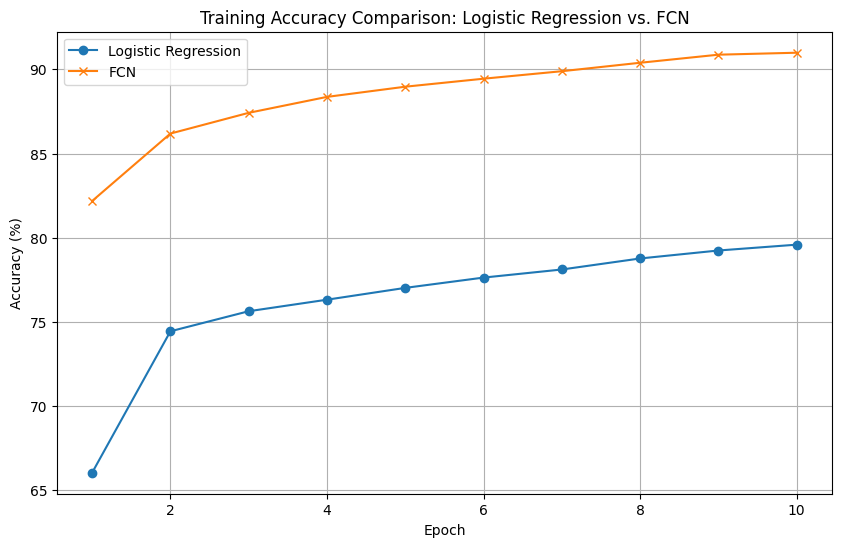

In [ ]:
# TODO: Plot
num_epochs = len(acc_LIST_log)
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, acc_LIST_log, label='Logistic Regression', marker = 'o')
plt.plot(epochs, acc_LIST_FCN, label='FCN', marker = 'x')
plt.title('Training Accuracy Comparison: Logistic Regression vs. FCN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

**The FCN outperforms the Logistic Regression model primarily because it possesses the capacity to learn non-linear relationships, whereas Logistic Regression is restricted to being a linear classifier. By incorporating a hidden layer with a non-linear activation function (such as ReLU), the FCN can transform the input data into a representation where it can capture complex, hierarchical patterns and decision boundaries that are not merely straight lines. This added structural depth allows the FCN to recognize intricate features within the Fashion-MNIST images.**

## **Part 4:** Hyperparameter Tuning

In this portion, we will go a step further and perform hyperparameter tuning on our FCN model as defined in Part 3. As you may recall, methods like grid search can help us to determine the optimal hyperparameter values needed to optimize model accuracy. This is also applicable to neural networks.

### 4.1: Learning Rates

**TODO:**
* Train a new `FCN` (as you previously defined the model architecture) for learning rates `[0.01, 0.001, 1e-4, 1e-5, 1e-6]`.
* For each learning rate, save a list of accuracies and losses for each of 10 epochs (if this step is taking too long, feel free to reduce this to 5 epochs).
* Plot these accuracies and losses in a side-by-side subplot [X manually graded points per graph].

In [ ]:
# Sending the data to device (CPU or GPU)
learning_rates = [0.01, 0.001, 1e-4, 1e-5, 1e-6]
acc_results = []
loss_results = []

for learning_rate in learning_rates:
  print(f"Training Model on Learning Rate {learning_rate}...")

  # TODO: Re-initialize model and criterion for every LR
  fcn = FCN().to(device)
  criterion = nn.CrossEntropyLoss()
  # END TODO

  optimizer = optim.Adam(fcn.parameters(), lr=learning_rate)
  num_epochs = 10

  # Train the FNN
  for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        labels = labels.type(torch.LongTensor) # TODO: Cast to Long
        inputs, labels = inputs.to(device), labels.to(device) # TODO: send to device

        # TODO
        optimizer.zero_grad()

        outputs = fcn(inputs)
        loss = criterion(outputs, labels)

        _, predicted = torch.max(outputs.data, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0) # accumulated loss

        correct += (predicted == labels).sum().item() # calculate correct predictions
        total += labels.size(0)

    # Calculate metrics
    accuracy = 100 * correct / total
    average_loss = running_loss / total

    # Append to the main flat lists
    acc_results.append(accuracy)
    loss_results.append(average_loss)

    # END TODO

    # print statistics
    print("The loss for Epoch {} is: {:.4f}, Accuracy = {:.2f}%".format(epoch + 1, average_loss, accuracy))
  print("=================================")



Training Model on Learning Rate 0.01...
The loss for Epoch 0 is: 34.40281324447599, Accuracy = 80.98333333333333
The loss for Epoch 1 is: 28.99922363793672, Accuracy = 83.87166666666667
The loss for Epoch 2 is: 27.9359999790883, Accuracy = 84.70166666666667
The loss for Epoch 3 is: 26.87358352421189, Accuracy = 85.17666666666666
The loss for Epoch 4 is: 26.619985531133885, Accuracy = 85.51833333333333
The loss for Epoch 5 is: 26.02454236829713, Accuracy = 85.81666666666666
The loss for Epoch 6 is: 25.150948517358124, Accuracy = 86.18166666666667
The loss for Epoch 7 is: 25.258250333098715, Accuracy = 85.97333333333333
The loss for Epoch 8 is: 24.8452311660181, Accuracy = 86.33333333333333
The loss for Epoch 9 is: 24.239060119271024, Accuracy = 86.47
Training Model on Learning Rate 0.001...
The loss for Epoch 0 is: 32.043250270998044, Accuracy = 82.04666666666667
The loss for Epoch 1 is: 24.2496063165319, Accuracy = 86.24166666666666
The loss for Epoch 2 is: 21.852473862389765, Accuracy

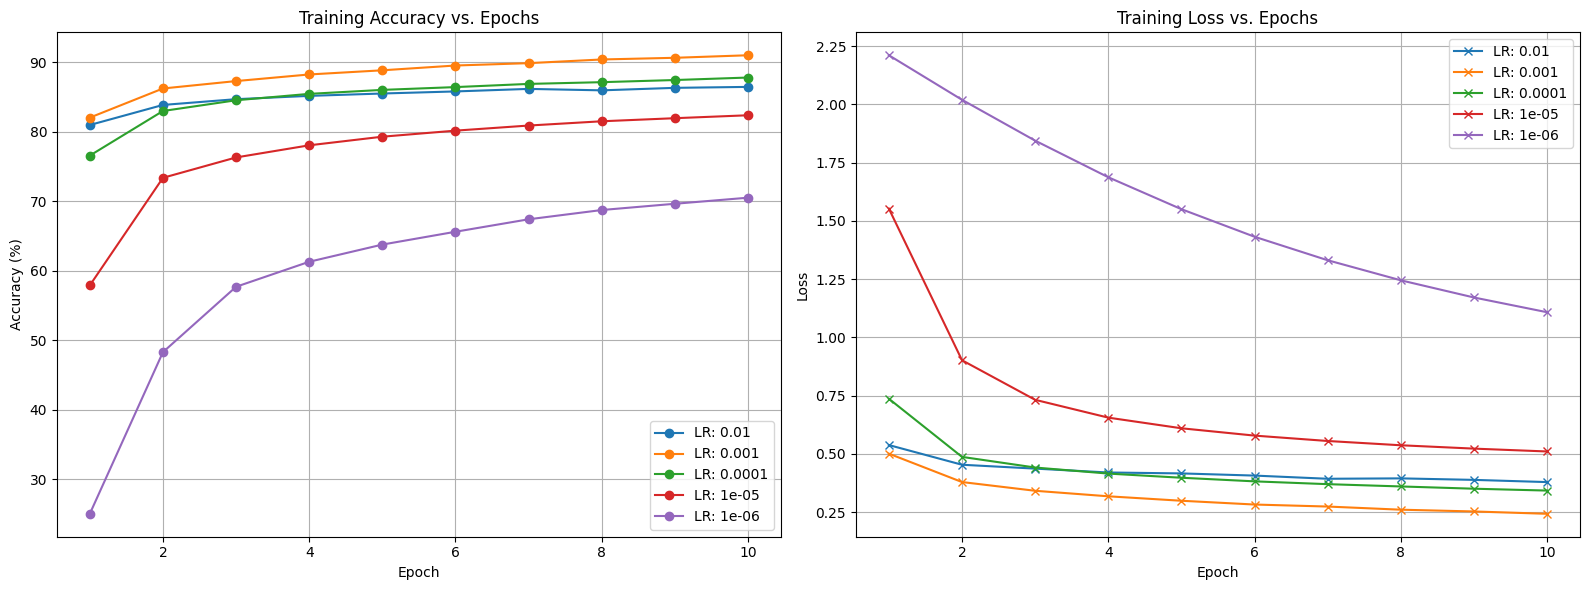

In [ ]:
# TODO: Create graph
epochs = range(1, 11)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for i, lr in enumerate(learning_rates):
    start = i * 10
    end = start + 10
    acc_chunk = acc_results[start:end]
    loss_chunk = loss_results[start:end]
    ax1.plot(epochs, acc_chunk, label=f'LR: {lr}', marker='o')
    ax2.plot(epochs, loss_chunk, label=f'LR: {lr}', marker='x')

ax1.set_title('Training Accuracy vs. Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True)

ax2.set_title('Training Loss vs. Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### 4.2: Reflection

Based on your graph from the previous problem, what are the consequences of:
* Too high of a learning rate?
**A learning rate that is too high (0.01) causes the optimizer to take steps that are bigger than necessary, making it repeatedly overshoot the minimum loss. This produces visible oscillations in the loss curve, showing that the model has trouble settling down and converging. In the graph, the 0.01 curve initially drops quickly, but it eventually levels off at a suboptimal accuracy and ends with a higher final loss compared with the ideal learning rate.**

* Too low of a learning rate?
**A learning rate that is too low (1e−6) causes the model to take extremely small steps, leading to very slow convergence and underfitting. The optimizer moves through the loss landscape at such a limited pace that it needs an impractically large number of epochs to make noticeable progress. As shown by the 1e−6 curve, the high final loss and low accuracy indicate that the model hardly improves, effectively stalling before it reaches acceptable performance.**

## Conclusion:

Unfortunately, as you can see, image classification using traditional techniques such as FCNs produces suboptimal results. There are more powerful deep learning algorithms, such as Convolutional Neural Networks (CNNs). You will have a chance to explore these algorithms in other parts of this homework!

In addition, there are other deep learning methods that are more suited to specific data types.




# Section 2: **CNN** (Convolutional Neural Networks)

In the last section of the HW, we saw how FCN's could be trained to classify images, although with suboptimal results. In this section, we'll finetune a Convolutional Neural Networks(CNN) on image classification tasks, and see how this architecture leverages convolutions to extract meaningful features from images! We'll be finetuning a ResNet50 architecture, which employs both convolutional layers and residual connections. Convolutions are often used to better extract local features from images, and residual connections help eliminate vanishing/explding gradients.

### 2.1 Convolutional Neural Networks

Like the previous section, we will load and transform the FashionMNIST dataset. However, instead of flattening, we are keeping the images' spatial structure. This is because while FCNs don’t use 2D convolutions but take vectors as input, CNNs need spatial information (height, width) preserved.

In [ ]:
# Define PyTorch Transform Object
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)), # To range [-1, 1]
])

# Define datsets
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True, num_workers = 0)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = True, num_workers = 0)

#### 2.1.1 Calculating Output Dimensions of Convolution and Pooling Layers

---
**TODO:**

Build the **feature_map_dim** function, which takes in the following four parameters and return the dimension of the output feature map.

- **input_dim**: height/width of the input image

- **kernel_size**: size of the convolving kernel (aka. filter)

- **padding**: padding added to all four sides of the input in order to preserve the edges/borders

- **stride**: Stride of the convolution, or how many shifts per kernel
  
ROUND DOWN if the result if a fraction.

---

Notice there is another parameter, "dilation", which is the spacing between kernel elements. We have not covered this in class; simply set it to 1.


In [ ]:
import math

def feature_map_dim(input_dim, padding, kernel_size, stride):
  '''
  The function takes in the following four parameters and return the dimension of the output feature map.

  input_dim: height/width of the input image
  kernel_size: size of the convolving kernel (aka. filter)
  padding: padding added to all four sides of the input in order to preserve the edges/borders
  stride: Stride of the convolution, or how many shifts per kernel

  ROUND DOWN if the result if a fraction.

  Notice there is another parameter, "dilation", which is the spacing between kernel elements. We have not covered this in class; simply set it to 1
  '''
  ## TODO

  dilation = 1
  numerator = input_dim + 2 * padding - kernel_size
  intermediate_result = numerator / stride
  output_dim = math.floor(intermediate_result) + 1

  ## END TODO
  return output_dim

#### 2.1.2 Create your own custom Convolutional Neural Network Architecture
For this section, you will be creating your own custom Convolutional Neural Network Architecture for this dataset. Typically, this would mean defining your neural network architecture within your `__init__` function of your Neural Network class. Within this initializer, you would define the individual layers of the network, which would typically consist of some number of `convolutional layers`, some number of `fully connected layers`, and other types of layers such as `pooling layers` and `dropout layers`.

One thing that you will need to pay attention to is how exactly the data is being input to your Convolutional Neural Network. That is, what are the input dimensions, and how does the dimensions of the data change as it is propagated through the network. Note that your choice of layering and the order of layers will determine the corresponding input and output dimensions of each layer.

---
**TODOs:**

`def __init__(self)`:
1.  Initialize some number of `convolutional blocks` (consists of a convolution layer, an activation function, and a Pooling layer)

2. `Flatten` the output of the convolution to a tensor

3. Initialize some number of `fully-connected layers`

`def forward(self, x)`:

4. Build the `forward` function/path with the layers initialized in `__init__` function.

---

- **Note:** While parameters of convolution layers tend to vary, it is possible to use the same pooling layer and activation function in each block. If you intend to use the same parameters for these two elements, then only 1 pooling layer and 1 activation function needs to be initialized.
- **Hint 1**: Use the `feature_map_dim` function to help you keep track of the input/output dimensions of each layer.
- **Hint 2**: The parameters you've calculated is particularly useful for the input dimensions for the linear layer in the first fully-connected layer.
- **Hint 3**: Each input is a grayscale (1 channel) 28 x 28 image.
- **Hint 4**: The final fully-connected layer's output dimension should be the same as the number of classes in our dataset.
- **Hint 5**: In order to raise training (and consequently testing) accuracy of the model, one should consider using some of the following strategies (see Lecture slides for more info):
    * Use [`nn.BatchNorm2d`](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html) or [`nn.LayerNorm`](https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html) in between the layers (after convolutional layer but before the activation function)
    * Implement residual connections (i.e., output of the block = input to the block + output of the last layer in the block)
    * Stack more blocks (e.g., Convolutional layers, Convolutional layers + Batch Normalization)

In [ ]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    #TODO
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 16, kernel_size = 5, padding = 0, stride = 1)
    self.bn1 = nn.BatchNorm2d(16)
    self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
    self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, padding = 0, stride = 1)
    self.bn2 = nn.BatchNorm2d(32)
    self.fc1 = nn.Linear(32 * 10 * 10, 512)
    self.fc2 = nn.Linear(512, 10)
    # END TODO

  def forward(self, x):
    #TODO
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.pool(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)

    x = self.flatten(x)

    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    # END TODO
    return x

In [ ]:
CNN()

CNN(
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=3200, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)

#### 2.1.3 Training CNN Model

---
**TODOs**
1.   Instantiate the CNN to the variable `cnn` (make sure to send this to the device env)
2.   Set the criterion as a CrossEntropyLoss (you can look up the documentation [here](https://pytorch.org/docs/stable/nn.html#loss-functions))
3.   Fill in the missing parts in the training loop.
4.   Calculate training accuracy for each epoch (should multiply by 100 to get percentage), store in variable called `accuracy`.
5.   Save the Training Accuracy for every epoch into `acc_LIST_CNN`
6.   Save the Average Loss for every epoch into `loss_LIST_CNN`

**Please do not modify the following set ups: **
- Optimizer: The optimizer is set as "Adam".
- Epoch: The epoch is set to "10".

---

**Hint:** Remember to update the weights correctly by backpropagation, please zero out the gradients by calling `optimizer.zero_grad()` every time you call `backward()`. Please review the `Recitation 10` for detailed instructions on how to perform these operations.

**Note 1**: If the loss went up during the training, there is something wrong with the model, so you should check if the model is implemented correctly.

**Note 2**: Typical training time takes between 5 - 10 mins.

**Note 3**: `acc_LIST_CNN` and `loss_LIST_CNN` should contain data of type float not tensor.

In [ ]:
from tqdm import tqdm

# TODO
cnn = CNN().to(device)
criterion = nn.CrossEntropyLoss()
# END TODO

optimizer = optim.Adam(cnn.parameters(), lr=1e-4) # lr stands for learning step
epoch = 10

acc_LIST_CNN = []
loss_LIST_CNN = []

# Train the CNN
for epoch in tqdm(range(epoch)):
  # Ensure model is in training mode
  cnn.train()

  running_loss = 0.0
  correct = 0
  total = 0

  for inputs, labels in train_loader:
      labels = labels.type(torch.LongTensor) # Note: labels.long() is the modern alternative
      inputs, labels = inputs.to(device), labels.to(device)

      # TODO
      # Step 1: Reset the optimizer tensor gradient every mini-batch
      optimizer.zero_grad()

      # Step 2: Feed the network the train data
      outputs = cnn(inputs)

      # Step 4: Find average loss for one mini-batch of inputs
      loss = criterion(outputs, labels)

      # Step 5: Do a back propagation
      loss.backward()

      # Step 6: Update the weight using the gradients from back propagation by learning step
      optimizer.step()

      # Step 3: Get the prediction using argmax (moved here for efficiency)
      _, predicted = torch.max(outputs.data, 1)

      # Step 7: Get loss and add to accumulated loss for each epoch
      running_loss += loss.item() * inputs.size(0)

      # Step 8: Get number of correct prediction and increment the number of correct and total predictions after this batch
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
      # END TODO

  # Step 9: Calculate training accuracy
  accuracy_value = (correct / total) * 100
  acc_LIST_CNN.append(torch.tensor(accuracy_value))

  # Step 10: Get average loss
  average_loss_value = running_loss / total
  loss_LIST_CNN.append(torch.tensor(average_loss_value))

  # print statistics
  print("The loss for Epoch {} is: {:.4f}, Accuracy = {:.2f}%".format(epoch, average_loss, accuracy))


 10%|█         | 1/10 [00:11<01:47, 11.94s/it]

The loss for Epoch 0 is: 0.0981, Accuracy = 96.70%


 20%|██        | 2/10 [00:20<01:19,  9.98s/it]

The loss for Epoch 1 is: 0.0981, Accuracy = 96.70%


 30%|███       | 3/10 [00:29<01:06,  9.51s/it]

...

The loss for Epoch 7 is: 0.0981, Accuracy = 96.70%


 90%|█████████ | 9/10 [01:22<00:08,  8.87s/it]

The loss for Epoch 8 is: 0.0981, Accuracy = 96.70%


100%|██████████| 10/10 [01:31<00:00,  9.17s/it]

The loss for Epoch 9 is: 0.0981, Accuracy = 96.70%


In [ ]:
# (if applicable)
# In order to pass the AutoGrader, every element in "acc_LIST_CNN" should be a float.
# If the elements are of type "Tensor", convert each element into type FLOAT by using .item() or .tolist()
# To check if each element is a Tensor, print out "acc_LIST_CNN" and see if there is a Tensor() wrapped around each element.
acc_LIST_CNN = [x.item() for x in acc_LIST_CNN]

#### 2.1.4 CNN Model Test Accuracy

---
**TODO:**
Calculate the Test Accuracy for the CNN Model we trained above by evaluating the percentage of correct classifications. Save it to the variable named `test_acc_CNN`, which is a PyTorch Tensor with one element.

---

In [ ]:
total = 0
correct = 0
cnn.eval()

with torch.no_grad():
    for images, labels in test_loader:
        # Data preparation and device transfer
        labels = labels.type(torch.LongTensor)
        images, labels = images.to(device), labels.to(device)

        # TODO
        outputs = cnn(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# TODO END

accuracy_float = (correct / total) * 100
test_acc_CNN = torch.tensor(accuracy_float)

print(f'Test Accuracy: {str(test_acc_CNN.item())}')

Test Accuracy: 90.26000213623047


###2.2 Pretraining and finetuning using ResNet50



#### 2.2.1: Initialize the model

In this part, we will prepare for finetuning by initializing the ResNet-50 model and changing the final layer.

---
**TODO**
1. Initialize the weights of the ResNet-50 using default weight or the V2 weight (look at [this documentation](https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet50.html#torchvision.models.ResNet50_Weights) for more information) as `weights`.
2. Initialize the model as `model` with the weights initialized before.
3. Change the last fully connected layer to have the output units the same as the number of classes.

---
**Note**: We are slightly modifying the ResNet50 model by changing its first layer to accept 1 channel due to the nature of the dataset.

**Hint**
* [This tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) by PyTorch might be helpful

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights
# TODO: initialize the Weight Transforms delete
num_classes = 10
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights = weights)
# TODO END

# Modify the first convolution layer to take 1-channel input instead of 3
old_conv = model.conv1
model.conv1 = nn.Conv2d(1, old_conv.out_channels,
                        kernel_size=old_conv.kernel_size,
                        stride=old_conv.stride,
                        padding=old_conv.padding,
                        bias=False)

# Initialize new conv1 weights by averaging old weights across RGB channels
with torch.no_grad():
    model.conv1.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))

# TODO: Get number of features for the head (final Fully Connected Layer)
# then change it to having output neurons of equivalent to number of classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
# REF: https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

# TODO END

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 69.6MB/s]


#### 2.2.2: Finetuning ResNet-50 Model
---
**TODOs:**
1.   Instantiate the modified ResNet-50 model to the variable `resnet`. Make sure to send this to the GPU device -- please consult the lab 9 notebook for a primer on how to do this.

2.   Set the loss criterion as `CrossEntropyLoss` (you can look up the documentation [here](https://pytorch.org/docs/stable/nn.html#loss-functions)). Note that softmax is already built into CrossEntropyLoss so if you use CrossEntropyLoss as the loss criterion, you don't need to add an additional softmax layer.

3.   Fill in the missing parts in the training loop (see `#TODO` comments below)
4.   Save the Training Accuracy for every epoch into the variable `acc_LIST_resnet`.
5.   Save the Average Loss for every epoch into the variable `loss_LIST_resnet`.
---
The optimizer is set as Adam -- **please do not modify the optimizer**.

**Hint**:
* Remember to update the weights correctly by backpropagation, please zero out the gradients by calling `optimizer.zero_grad()` every time you call `backward()`.

**Note: If the loss went up during the training, there is something wrong with the model, so you should check if the model is implemented correctly**

**Note 2**: <font color='red'>If the accuracy is pretty low (10th or last epoch has accuracy < 80), try to maybe initialize another model which has a larger number of parameters (e.g., [ResNet-101 or ResNet-152](https://pytorch.org/vision/stable/models/resnet.html)) and try to initialize it the same way you did for **3.1** including reset the last layer and change the pretrained weights.</font>

In [ ]:
%%time
start = time.time()
## Sending the data to device (CPU or GPU)
# TODO
resnet = model.to(device) # 1. Instantiate/Move the modified ResNet-50 model to device
criterion = nn.CrossEntropyLoss() # 2. Set the loss criterion as CrossEntropyLoss
# END TODO

optimizer = optim.Adam(resnet.parameters(), lr=1e-4) #lr - learning step
epoch = 10

acc_LIST_resnet = []
loss_LIST_resnet = []

# Train the ResNet
for epoch in range(epoch):
    start_of_loop = time.time()
    # Set model to training mode
    resnet.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        labels = labels.type(torch.LongTensor) # Ensure LongTensor for CrossEntropyLoss
        inputs, labels = inputs.to(device), labels.to(device)

        # TODO
        # Step 1: Reset the optimizer tensor gradient every mini-batch
        optimizer.zero_grad()

        # Step 2: Feed the network the train data (Forward Pass)
        outputs = resnet(inputs)

        # Step 4: Find average loss for one mini-batch of inputs
        loss = criterion(outputs, labels)

        # Step 5: Do a back propagation
        loss.backward()

        # Step 6: Update the weight using the gradients from back propagation by learning step
        optimizer.step()

        # Step 3: Get the prediction using argmax
        _, predicted = torch.max(outputs.data, 1)

        # Step 7: Get loss and add to accumulated loss for each epoch
        running_loss += loss.item() * inputs.size(0)

        # Step 8: Get number of correct prediction and increment the number of correct and total predictions after this batch
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Step 9: Calculate training accuracy for each epoch (should multiply by 100 to get percentage), store in variable called 'accuracy', and add to acc_LIST_resnet
    accuracy = (correct / total) * 100
    acc_LIST_resnet.append(accuracy)

    # Step 10: Get average loss for each epoch and add to loss_LIST_resnet
    average_loss = running_loss / total
    loss_LIST_resnet.append(average_loss)

    # END TODO

    # print statistics
    print("The loss for Epoch {} is: {:.4f}, Accuracy = {:.2f}% with time {:.2f}s".format(
        epoch, average_loss, accuracy, time.time() - start_of_loop))

print("====================")
print("Overall time = {:.2f}s".format(time.time() - start))

The loss for Epoch 0 is: 0.5760, Accuracy = 80.44% with time 57.58s
The loss for Epoch 1 is: 0.2605, Accuracy = 90.58% with time 64.90s
The loss for Epoch 2 is: 0.1985, Accuracy = 92.75% with time 56.48s
The loss for Epoch 3 is: 0.1597, Accuracy = 94.21% with time 56.93s
The loss for Epoch 4 is: 0.1271, Accuracy = 95.35% with time 57.14s
The loss for Epoch 5 is: 0.1016, Accuracy = 96.30% with time 57.13s
The loss for Epoch 6 is: 0.0840, Accuracy = 96.97% with time 57.30s
The loss for Epoch 7 is: 0.0694, Accuracy = 97.50% with time 57.20s
The loss for Epoch 8 is: 0.0572, Accuracy = 98.00% with time 57.17s
The loss for Epoch 9 is: 0.0506, Accuracy = 98.22% with time 57.34s
Overall time = 579.19s
CPU times: user 9min 22s, sys: 1.26 s, total: 9min 24s
Wall time: 9min 39s


#### 2.2.3: Finetuned ResNet-50 Accuracy

Similar to what we have done before in the training loop, here we are looping through the `test_loader` and calculate the test accuracy, which is akin to going through the dataset only once without learning anything new (i.e., `with torch.no_grad()` and `resnet.eval()` are used to turn off gradients computation and turn off some layers such as `BatchNorm`, respectively). For more information, see [this](https://stackoverflow.com/a/60018731).

---
**TODO**
1. Calculate the test accuracy, stored as `test_acc_resnet` which is a PyTorch Tensor with one element.

---

In [ ]:
total = 0
correct = 0
resnet.eval()
with torch.no_grad():
    for images, labels in test_loader:
        labels = labels.type(torch.LongTensor)
        images, labels = images.to(device), labels.to(device)

        # TODO
        outputs = resnet(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        # END TODO

accuracy_float = (correct / total) * 100
test_acc_resnet = torch.tensor(accuracy_float)

# TODO END

print(f'Test Accuracy: ' + str(test_acc_resnet.item()))

Test Accuracy: 91.5199966430664


# Section 3: Transformers and LLMs

### What are transformers?

Transformer models are the gold standard for natural language processing tasks. This encompasses machine translation, text generation, representation learning, and more.

### Encoders
Encoders in transformer models are designed to process input data (e.g., text) and generate a rich, context-aware representation of the data. The input sequence is first embedded into continuous vector spaces using embeddings, which are then augmented with positional encodings to incorporate the order of the sequence. The encoder consists of multiple identical layers, each with:

Multi-Head Self-Attention: This mechanism allows the model to focus on different parts of the input simultaneously, capturing relationships between words or tokens irrespective of their distance in the sequence.

Feed-Forward Neural Networks: These layers further transform the representations after the self-attention mechanism.

Residual Connections and Layer Normalization: These are added to ensure stable training and efficient gradient flow.

The encoder ultimately produces contextual embeddings for every token in the input, encapsulating the meaning and relevance of each token within its surrounding context.

### Decoders
Decoders are tasked with generating an output sequence, often one token at a time, based on the input processed by the encoder and previously generated tokens. Like encoders, decoders also consist of multiple layers, but with key differences:

Masked Multi-Head Self-Attention: This ensures that the decoder cannot "see" future tokens during training, maintaining the autoregressive nature of sequence generation.

Cross-Attention: This layer focuses on the encoder's output, aligning the decoder's processing with relevant parts of the input sequence.

Feed-Forward Neural Networks: Similar to the encoder, these layers refine the representations at each step.

Decoders iteratively generate the output sequence, using the previous output token to predict the next.

### Encoder-Decoder

The encoder-decoder architecture integrates both components to enable tasks such as machine translation and sequence-to-sequence learning. The encoder processes the input sequence to produce a context-rich representation, which is then fed into the decoder. The decoder uses this representation along with its own self-attention and cross-attention mechanisms to generate the output sequence step by step.

For example, in machine translation, the encoder processes a sentence in the source language, creating a representation that the decoder uses to generate the equivalent sentence in the target language. The architecture's design ensures effective information flow between the input and output sequences while maintaining contextual accuracy.

## 3.0: Libraries and setup

### Set device to GPU

**First, make sure you are switched to a GPU runtime by going to Runtime -> Change runtime type -> T4 GPU**

In [ ]:
# DO NOT MODIFY
import torch
torch.manual_seed(42) # For grading consistency

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(torch.__version__)
print(device)

2.9.0+cu126
cuda:0


In [ ]:
device

device(type='cuda', index=0)

In [ ]:
# this should pass
assert device.type == 'cuda'

### Login with Huggingface

To use the model later in the notebook, you will have to login into Hugging Face and paste in your authentication token. Steps:


1. Create a Hugging Face account if you haven't already: https://huggingface.co/welcome

2. Create an authentication token. Go to your settings, then click on the Access Tokens tab. Click on the New token button to create a new User Access Token

3. Run the cell below and paste in your token and username

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

First, we install the Huggingface datasets and transformers package.

[datasets](https://huggingface.co/docs/datasets/en/index)  helps us load in a dataset.

[transformers](https://huggingface.co/docs/transformers/en/index) helps us load in a model.

[evaluate](https://huggingface.co/spaces/evaluate-metric/squad_v2) helps us evaluate our model


In [ ]:
! pip install datasets
! pip install transformers
! pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


## Task: Fine-tuning a model on a question-answering task

In this assignment, we will see how to fine-tune one of the Huggingface (🤗) [ Transformers](https://github.com/huggingface/transformers) model to a question answering task, which is the task of extracting the answer to a question from a given context. We will see how to load a dataset for these kinds of tasks and use the `Trainer` API to fine-tune a model on it.

Fine tuning is a useful skill when creating LLM applications because LLMs are computationally intensive to train. Therefore, it's common to take a pretrained LLM and fine tune it for a particular use case.

**Note:** This notebook finetunes models that answer questions by taking a substring of a context, not by generating new text.

SQuAD = Stanford Question Answering Dataset. The model gets a context paragraph + question, and it must return a span from the context.

SQuAD v1.1:
Every question has at least one answer span in the context.

During training/inference you never need to say “no answer.”

SQuAD v2.0:
Mix of answerable questions (like v1), and unanswerable questions where the correct behavior is “there is no answer in this passage.”

In [ ]:
# This flag is the difference between SQUAD v1 or 2 (if you're using another dataset, it indicates if impossible
# answers are allowed or not).
squad_v2 = False
model_checkpoint = "distilbert-base-uncased"
batch_size = 16

### Loading the dataset

We will use the Huggingface [Datasets](https://github.com/huggingface/datasets) library to download the data and get the metric we need to use for evaluation (to compare our model to the benchmark). This can be easily done with the functions `load_dataset` and `load_metric`.  

In [ ]:
from datasets import load_dataset

For our example here, we'll use the [SQUAD dataset](https://rajpurkar.github.io/SQuAD-explorer/).

In [ ]:
datasets = load_dataset("squad_v2" if squad_v2 else "squad")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

The `datasets` object itself is [`DatasetDict`](https://huggingface.co/docs/datasets/package_reference/main_classes.html#datasetdict), which contains one key for the training, validation and test set.

In [ ]:
datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})

To shorten the training time, we are going to select
- 8000 rows from the training set
- 2000 rows from the validation set

Note that this will lead to worse results compared to a model fine tuned on all of the examples. But since the purpose of this assignment is to show you the process of fine tuning, we will focus less on the actual performance of the model.

In [ ]:
datasets["train"] = datasets["train"].select(range(8000))
datasets["validation"] = datasets["validation"].select(range(2000))

We can see the training, validation and test sets all have a column for the context, the question and the answers to those questions.

To access an actual element, you need to select a split first, then give an index:

In [ ]:
datasets["train"][0]

{'id': '5733be284776f41900661182',
 'title': 'University_of_Notre_Dame',
 'context': 'Architecturally, the school has a Catholic character. Atop the Main Building\'s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.',
 'question': 'To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?',
 'answers': {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}}

We can see the answers are indicated by their start position in the text (here at character 515) and their full text, which is a substring of the context as we mentioned above.

To get a sense of what the data looks like, the following function will show some examples picked randomly in the dataset (automatically decoding the labels in passing).

In [ ]:
from datasets import ClassLabel, Sequence
import random
import pandas as pd
from IPython.display import display, HTML

def show_random_elements(dataset, num_examples=10):
    assert num_examples <= len(dataset), "Can't pick more elements than there are in the dataset."
    picks = []
    for _ in range(num_examples):
        pick = random.randint(0, len(dataset)-1)
        while pick in picks:
            pick = random.randint(0, len(dataset)-1)
        picks.append(pick)

    df = pd.DataFrame(dataset[picks])
    for column, typ in dataset.features.items():
        if isinstance(typ, ClassLabel):
            df[column] = df[column].transform(lambda i: typ.names[i])
        elif isinstance(typ, Sequence) and isinstance(typ.feature, ClassLabel):
            df[column] = df[column].transform(lambda x: [typ.feature.names[i] for i in x])
    display(HTML(df.to_html()))

In [ ]:
show_random_elements(datasets["train"])

,id,title,context,question,answers
0,56cd6e9062d2951400fa65ad,Sino-Tibetan_relations_during_the_Ming_dynasty,"Wylie asserts that this type of censorship of the History of Ming distorts the true picture of the history of Sino-Tibetan relations, while the Ming court granted titles to various lamas regardless of their sectarian affiliations in an ongoing civil war in Tibet between competing Buddhist factions. Wylie argues that Ming titles of ""King"" granted indiscriminately to various Tibetan lamas or even their disciples should not be viewed as reappointments to earlier Yuan dynasty offices, since the viceregal Sakya regime established by the Mongols in Tibet was overthrown by the Phagmodru myriarchy before the Ming existed.",Who was the viceregal Sakya regime overthrown by?,"{'text': ['the Phagmodru myriarchy'], 'answer_start': [573]}"
1,5733e44a4776f41900661440,Anthropology,"Urban anthropology is concerned with issues of urbanization, poverty, and neoliberalism. Ulf Hannerz quotes a 1960s remark that traditional anthropologists were ""a notoriously agoraphobic lot, anti-urban by definition"". Various social processes in the Western World as well as in the ""Third World"" (the latter being the habitual focus of attention of anthropologists) brought the attention of ""specialists in 'other cultures'"" closer to their homes. There are two principle approaches in urban anthropology: by examining the types of cities or examining the social issues within the cities. These two methods are overlapping and dependent of each other. By defining different types of cities, one would use social factors as well as economic and political factors to categorize the cities. By directly looking at the different social issues, one would also be studying how they affect the dynamic of the city.",What is a stereotype of traditional anthropologists?,"{'text': ['notoriously agoraphobic'], 'answer_start': [164]}"
2,56cdcb2c62d2951400fa6834,2008_Sichuan_earthquake,"It is also known as the Wenchuan earthquake (Chinese: 汶川大地震; pinyin: Wènchuān dà dìzhèn; literally: ""Great Wenchuan earthquake""), after the location of the earthquake's epicenter, Wenchuan County, Sichuan. The epicenter was 80 kilometres (50 mi) west-northwest of Chengdu, the provincial capital, with a focal depth of 19 km (12 mi). The earthquake was also felt in nearby countries and as far away as both Beijing and Shanghai—1,500 km (930 mi) and 1,700 km (1,060 mi) away—where office buildings swayed with the tremor. Strong aftershocks, some exceeding magnitude 6, continued to hit the area even months after the main quake, causing new casualties and damage.",How long after the earthquake were aftershocks felt?,"{'text': ['months after'], 'answer_start': [601]}"
3,56cf6057aab44d1400b89177,Kanye_West,"Kanye West began his early production career in the mid-1990s, making beats primarily for burgeoning local artists, eventually developing a style that involved speeding up vocal samples from classic soul records. His first official production credits came at the age of nineteen when he produced eight tracks on Down to Earth, the 1996 debut album of a Chicago rapper named Grav. For a time, West acted as a ghost producer for Deric ""D-Dot"" Angelettie. Because of his association with D-Dot, West wasn't able to release a solo album, so he formed and became a member and producer of the Go-Getters, a late-1990s Chicago rap group composed of him, GLC, Timmy G, Really Doe, and Arrowstar. His group was managed by John ""Monopoly"" Johnson, Don Crowley, and Happy Lewis under the management firm Hustle Period. After attending a series of promotional photo shoots and making some radio appearances, The Go-Getters released their first and only studio album World Record Holders in 1999. The album featured other Chicago-based rappers such as Rhymefest, Mikkey Halsted, Miss Criss, and Shayla G. Meanwhile, the production was handled by West, Arrowstar, Boogz, and Brian ""All Day"" Miller.",Who were the beats Kan

## 3.1: Preprocessing the training data

Before we can feed those texts to our model, we need to preprocess them. This is done by a 🤗 Transformers `Tokenizer` which will (as the name indicates) tokenize the inputs (including converting the tokens to their corresponding IDs in the pretrained vocabulary) and put it in a format the model expects, as well as generate the other inputs that model requires.

What are tokens?
These are units of language that the model processes (ex: word, character, ngram, phrase).

To do all of this, we instantiate our tokenizer with the `AutoTokenizer.from_pretrained` method, which will ensure:

- we get a tokenizer that corresponds to the model architecture we want to use,
- we download the vocabulary used when pretraining this specific checkpoint.

That vocabulary will be cached, so it's not downloaded again the next time we run the cell.

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

The following assertion ensures that our tokenizer is a fast tokenizers (backed by Rust) from the 🤗 Tokenizers library. Those fast tokenizers are available for almost all models, and we will need some of the special features they have for our preprocessing.

In [ ]:
import transformers
assert isinstance(tokenizer, transformers.PreTrainedTokenizerFast)

You can check which type of models have a fast tokenizer available and which don't on the [big table of models](https://huggingface.co/transformers/index.html#bigtable).

You can directly call this tokenizer on two sentences (one for the answer, one for the context):

In [ ]:
tokenizer("What is your name?", "My name is Aashvi.")

{'input_ids': [101, 2054, 2003, 2115, 2171, 1029, 102, 2026, 2171, 2003, 9779, 4095, 5737, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

You might be wondering what this output means.

- input_ids = the indices from the vocabulary corresponding to each token in the sentence
- attention_mask = whether a token should be attended to or not. In this case, we haven't started training yet so all of the tokens are initialized with activation_mask=1

Tokens are not necessarily words. They can be phrases, special characters, and more. How a token is defined depends on what model you use. Many models also like to use padding so that regardless of what text is passed into the tokenizer, the output list of tokens will have the same length (if a sentence is shorter than the length, the remainder of the tokens would be filler values, like 0s)


The vocabulary on these tokenizers are quite expansive but if it encounters a token it's never seen before (which is rare), it will get classified as a special character.


For more info about tokenizers: https://huggingface.co/docs/transformers/preprocessing

### 3.1.1 Creating a Tokenizer

Now one specific thing for the preprocessing in question answering is how to deal with very long documents. We usually truncate them in other tasks, when they are longer than the model maximum sentence length, but here, removing part of the the context might result in losing the answer we are looking for.

To deal with this, we will allow one (long) example in our dataset to give several input features, each of length shorter than the maximum length of the model (or the one we set as a hyper-parameter).

Also, just in case the answer lies at the point we split a long context, we allow some overlap between the features we generate controlled by the hyper-parameter `doc_stride`:

In [ ]:
max_length = 384 # The maximum length of feature (question and context)
doc_stride = 128 # The authorized overlap between two parts of the context when splitting it is needed.

Let's find one long example in our dataset:

In [ ]:
for i, example in enumerate(datasets["train"]):
    if len(tokenizer(example["question"], example["context"])["input_ids"]) > max_length:
        break
example = datasets["train"][i]

In [ ]:
example

{'id': '5733caf74776f4190066124c',
 'title': 'University_of_Notre_Dame',
 'context': "The men's basketball team has over 1,600 wins, one of only 12 schools who have reached that mark, and have appeared in 28 NCAA tournaments. Former player Austin Carr holds the record for most points scored in a single game of the tournament with 61. Although the team has never won the NCAA Tournament, they were named by the Helms Athletic Foundation as national champions twice. The team has orchestrated a number of upsets of number one ranked teams, the most notable of which was ending UCLA's record 88-game winning streak in 1974. The team has beaten an additional eight number-one teams, and those nine wins rank second, to UCLA's 10, all-time in wins against the top team. The team plays in newly renovated Purcell Pavilion (within the Edmund P. Joyce Center), which reopened for the beginning of the 2009–2010 season. The team is coached by Mike Brey, who, as of the 2014–15 season, his fifteenth at Notre

Without any truncation, we get the following length for the input IDs:

In [ ]:
len(tokenizer(example["question"], example["context"])["input_ids"])

396

Now, if we just truncate, we will lose information (and possibly the answer to our question):

In [ ]:
len(tokenizer(example["question"], example["context"], max_length=max_length)["input_ids"])

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


384

You should see a warning that says "Truncation was not explicitly activated but `max_length` is provided a specific value..."

We need to define a truncation strategy. That is, we are passing in both a question and answer to the tokenizer and we are telling the tokenizer to chop off one of these (question or answer) such that the total number of tokens is at most max_length.

In a question answering task, what would we rather truncate - the question or the context? (think about what is more important to retain)

Based on your answer, choose a parameter for truncation:

- True or 'longest_first': truncate to a maximum length specified by the max_length argument or the maximum length accepted by the model if no max_length is provided (max_length=None). This will truncate token by token, removing a token from the longest sequence in the pair until the proper length is reached.
- 'only_second': truncate to a maximum length specified by the max_length argument or the maximum length accepted by the model if no max_length is provided (max_length=None). This will only truncate the second sentence of a pair if a pair of sequences (or a batch of pairs of sequences) is provided.
- 'only_first': truncate to a maximum length specified by the max_length argument or the maximum length accepted by the model if no max_length is provided (max_length=None). This will only truncate the first sentence of a pair if a pair of sequences (or a batch of pairs of sequences) is provided.
- False or 'do_not_truncate': no truncation is applied. This is the default behavior.

([from huggingface documentation](https://huggingface.co/docs/transformers/en/pad_truncation))

In [ ]:
# TODO: choose a truncation parameter based on your answer to the above question
truncation = "only_second"

Now, we will define a tokenizer. Keep in mind max_length, truncation, doc_stride, and other parameters to ensure we capture the overlap between truncations.

You should pass in the example question, example context, max_length, truncation, stride, and return_overflowing_tokens. We also want to set `return_offsets_mapping` to True so that we can get the start and end char in the features for each token. This will help the model understand what part of the context the answer lies in.

In [ ]:
# TODO: tokenize our example based on what we discussed above
tokenized_example = tokenizer(
    example['question'],
    example["context"],

    max_length = max_length,
    truncation = 'only_second',
    stride = doc_stride,
    return_overflowing_tokens = True,

    return_offsets_mapping = True
)

Now you should not have one list of token `input_ids`, but several:

In [ ]:
tokenized_check = [len(x) for x in tokenized_example["input_ids"]]
print(tokenized_check)

[384, 157]


And if we decode them, you should be able to see an overlap:

In [ ]:
for x in tokenized_example["input_ids"][:2]:
    print(tokenizer.decode(x))

[CLS] how many wins does the notre dame men ' s basketball team have? [SEP] the men ' s basketball team has over 1, 600 wins, one of only 12 schools who have reached that mark, and have appeared in 28 ncaa tournaments. former player austin carr holds the record for most points scored in a single game of the tournament with 61. although the team has never won the ncaa tournament, they were named by the helms athletic foundation as national champions twice. the team has orchestrated a number of upsets of number one ranked teams, the most notable of which was ending ucla ' s record 88 - game winning streak in 1974. the team has beaten an additional eight number - one teams, and those nine wins rank second, to ucla ' s 10, all - time in wins against the top team. the team plays in newly renovated purcell pavilion ( within the edmund p. joyce center ), which reopened for the beginning of the 2009 – 2010 season. the team is coached by mike brey, who, as of the 2014 – 15 season, his fifteenth

### 3.1.2 Specifying location of answer in context

Let's check offset mappings for the first list of tokens.

In [ ]:
print(tokenized_example["offset_mapping"][0][:100])

[(0, 0), (0, 3), (4, 8), (9, 13), (14, 18), (19, 22), (23, 28), (29, 33), (34, 37), (37, 38), (38, 39), (40, 50), (51, 55), (56, 60), (60, 61), (0, 0), (0, 3), (4, 7), (7, 8), (8, 9), (10, 20), (21, 25), (26, 29), (30, 34), (35, 36), (36, 37), (37, 40), (41, 45), (45, 46), (47, 50), (51, 53), (54, 58), (59, 61), (62, 69), (70, 73), (74, 78), (79, 86), (87, 91), (92, 96), (96, 97), (98, 101), (102, 106), (107, 115), (116, 118), (119, 121), (122, 126), (127, 138), (138, 139), (140, 146), (147, 153), (154, 160), (161, 165), (166, 171), (172, 175), (176, 182), (183, 186), (187, 191), (192, 198), (199, 205), (206, 208), (209, 210), (211, 217), (218, 222), (223, 225), (226, 229), (230, 240), (241, 245), (246, 248), (248, 249), (250, 258), (259, 262), (263, 267), (268, 271), (272, 277), (278, 281), (282, 285), (286, 290), (291, 301), (301, 302), (303, 307), (308, 312), (313, 318), (319, 321), (322, 325), (326, 330), (330, 331), (332, 340), (341, 351), (352, 354), (355, 363), (364, 373), (374,

This gives, for each index of our input IDS, the corresponding start and end character in the original text that gave our token. The very first token (`[CLS]`) has (0, 0) because it doesn't correspond to any part of the question/answer, then the second token is the same as the characters 0 to 3 of the question:

In [ ]:
first_token_id = tokenized_example["input_ids"][0][1]
offsets = tokenized_example["offset_mapping"][0][1]
print(tokenizer.convert_ids_to_tokens([first_token_id])[0], example["question"][offsets[0]:offsets[1]])

how How


So we can use this mapping to find the position of the start and end tokens of our answer in a given feature. We just have to distinguish which parts of the offsets correspond to the question and which part correspond to the context, this is where the `sequence_ids` method of our `tokenized_example` can be useful:

In [ ]:
sequence_ids = tokenized_example.sequence_ids()
print(sequence_ids)

[None, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, None, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

It returns `None` for the special tokens, then 0 or 1 depending on whether the corresponding token comes from the first text passed (the question) or the second (the context). Now with all of this, we can find the first and last token of the answer in one of our input feature (or if the answer is not in this feature):

**TODO: get_start_end_token_index**

This function returns the start and end indices of the answer tokens. Fill out the empty TODOs in this function

In [ ]:
def get_start_end_token_index(answers, offsets, total_length, cls_index, sequence_ids, verbose=False):
  """
  Returns:
  (start_token_index, end_token_index)
  """

  # TODO: check if no answers are given. then return cls_index as start and end token indices
  if len(answers["answer_start"]) == 0:
      return cls_index, cls_index

  # TODO: Define the start/end character index of the answer in the text.
  start_char = answers["answer_start"][0]
  end_char = start_char + len(answers["text"][0])

  # Start token index of the current span in the text.
  token_start_index = 0
  # Move token_start_index past the special tokens and question tokens (sequence_id 0)
  while sequence_ids[token_start_index] != (1):
      token_start_index += 1

  # End token index of the current span in the text.
  token_end_index = total_length - 1
  # Move token_end_index back past the special tokens (sequence_id None)
  while sequence_ids[token_end_index] != (1):
      token_end_index -= 1

  # TODO: check whether the first token starts before the answer and that the last token ends after the answer
  # hint: recall that offsets gives us the start and end chars of each token in an example
  if offsets[token_start_index][0] > start_char or offsets[token_end_index][1] < end_char:
      # TODO: return cls_index as start and end
      # If the answer is not fully contained within this feature chunk, predict [CLS]
      return cls_index, cls_index
  else:
      # TODO: Move the token_start_index and token_end_index to the two ends of the answer.

      while token_start_index < total_length and offsets[token_start_index][0] <= start_char:
          if offsets[token_start_index][0] == start_char:
              break
          token_start_index += 1

      while token_end_index >= 0 and offsets[token_end_index][1] >= end_char:
          if offsets[token_end_index][1] == end_char:
              break
          token_end_index -= 1

      while token_start_index < total_length and offsets[token_start_index][0] < start_char:
          token_start_index += 1

      while token_end_index >= 0 and offsets[token_end_index][1] > end_char:
          token_end_index -= 1

      return token_start_index, token_end_index

And we can double check that it is indeed the theoretical answer:

In [ ]:
# TEST ON AN EXAMPLE

index = 0

# Get an example from the dataset
example = datasets["train"][index]

# TODO: Tokenize the example similar to how you did before
tokenized_example = tokenizer(
    example["question"],
    example["context"],
    max_length=max_length,
    truncation="only_second",
    stride=doc_stride,
    return_overflowing_tokens=True,
    return_offsets_mapping=True
)
# Get sequence IDs and offsets
sequence_ids = tokenized_example.sequence_ids()
offsets = tokenized_example["offset_mapping"][0]
total_length = len(tokenized_example["input_ids"][0])
cls_index = tokenized_example["input_ids"][0].index(tokenizer.cls_token_id)

# Get start and end positions
start_position, end_position = get_start_end_token_index(
    example["answers"],
    offsets,
    total_length,
    cls_index,
    sequence_ids,
    verbose=True
)

# Get the predicted answer span
predicted_answer = tokenizer.decode(tokenized_example["input_ids"][0][start_position:end_position+1])
actual_answer = example["answers"]["text"][0]

print("Predicted answer:", predicted_answer)
print("Actual answer:", actual_answer)

Predicted answer: saint bernadette soubirous
Actual answer: Saint Bernadette Soubirous


In [ ]:
index = 1

# Get an example from the dataset
example = datasets["train"][index]

# TODO: Tokenize the example similar to how you did before
tokenized_example = tokenizer(
    example["question"],
    example["context"],
    max_length=max_length,
    truncation="only_second",
    stride=doc_stride,
    return_overflowing_tokens=True,
    return_offsets_mapping=True
)

# Get sequence IDs and offsets
sequence_ids = tokenized_example.sequence_ids()
offsets = tokenized_example["offset_mapping"][0]
total_length = len(tokenized_example["input_ids"][0])
cls_index = tokenized_example["input_ids"][0].index(tokenizer.cls_token_id)

# Get start and end positions
start_position, end_position = get_start_end_token_index(
    example["answers"],
    offsets,
    total_length,
    cls_index,
    sequence_ids,
    verbose=True
)

# Get the predicted answer span
predicted_answer2 = tokenizer.decode(tokenized_example["input_ids"][0][start_position:end_position+1])
actual_answer = example["answers"]["text"][0]

print("Predicted answer:", predicted_answer2)
print("Actual answer:", actual_answer)

Predicted answer: a copper statue of christ
Actual answer: a copper statue of Christ


### 3.1.3 Putting everything together to prepare training features

Now let's put everything together in one function we will apply to our training set.

In the case of impossible answers (the answer is in another feature given by an example with a long context), we set the cls index for both the start and end position. We could also simply discard those examples from the training set if the flag `allow_impossible_answers` is `False`. Since the preprocessing is already complex enough as it is, we've kept is simple for this part.

In [ ]:
def prepare_train_features(examples, verbose=False):
    """
    Returns:
    tokenized_examples
    """
    # The number of classes for Fashion-MNIST
    num_classes = 10

    # TODO: remove the whitespace on the left for each question in examples
    # HINT: use .lstrip()
    examples["question"] = [q.lstrip() for q in examples["question"]]


    # TODO: tokenize the examples like you did earlier in the notebook. Set padding to "max_length"
    tokenized_examples = tokenizer(
        examples["question"],
        examples["context"],
        max_length=max_length,
        truncation="only_second",
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",  # Set padding to max_length
    )

    # Since one example might give us several features if it has a long context, we need a map from a feature to
    # its corresponding example.
    # TODO: get the overflow_to_sample_mapping from the tokenized_examples
    sample_mapping = tokenized_examples.overflow_to_sample_mapping

    # The offset mappings will give us a map from token to character position in the original context. This will
    # help us compute the start_positions and end_positions.
    # TODO: get the offset_mapping from the tokenized_examples
    offset_mapping = tokenized_examples["offset_mapping"]

    # Now we will label the tokenized_examples
    tokenized_examples["start_positions"] = []
    tokenized_examples["end_positions"] = []

    # Get the CLS token ID for non-existent answers
    cls_token_id = tokenizer.cls_token_id

    for i, offsets in enumerate(offset_mapping):
        # We will label nonexistent answers with the index of the CLS token.
        input_ids = tokenized_examples["input_ids"][i]

        # Get the sequence ids corresponding to example i (hint: use .sequence_ids())
        sequence_ids = tokenized_examples.sequence_ids(i)

        # One example can give several spans, this is the index of the example containing this span of text.
        sample_index = sample_mapping[i]
        answers = examples["answers"][sample_index]

        # Determine the CLS index for this specific feature chunk
        try:
            cls_index = input_ids.index(cls_token_id)
        except ValueError:
            # Handle case where CLS token might be missing (shouldn't happen with padding='max_length')
            cls_index = 0

        # Call the helper function to get token indices
        start, end = get_start_end_token_index(
            answers,
            offsets,
            len(input_ids),
            cls_index,
            sequence_ids
        )

        # Append the results
        tokenized_examples["start_positions"].append(start)
        tokenized_examples["end_positions"].append(end)

        # If verbose is True, print out start and end indices
        if (verbose):
          print(f'{start}, {end}')


    return tokenized_examples

This function works with one or several examples. In the case of several examples, the tokenizer will return a list of lists for each key:

In [ ]:
features = prepare_train_features(datasets['train'][:5], verbose=True)

130, 137
52, 56
81, 83
95, 101
33, 39


In [ ]:
# TODO: copy over the debug output (start and end positions) for the first 5 examples in the form
"""
example:

12 191
39 45
5 16
87 101
22 55

result =
[
  [12, 191],
  [39, 45],
  [5, 16],
  [87. 101],
  [22, 55]
]
"""

result = [
  [130, 137],
  [52, 56],
  [81, 83],
  [95, 101],
  [33, 39]
]

To apply this function on all the sentences (or pairs of sentences) in our dataset, we just use the `map` method of our `dataset` object we created earlier. This will apply the function on all the elements of all the splits in `dataset`, so our training, validation and testing data will be preprocessed in one single command. Since our preprocessing changes the number of samples, we need to remove the old columns when applying it.

In [ ]:
tokenized_datasets = datasets.map(prepare_train_features, batched=True, remove_columns=datasets["train"].column_names)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Even better, the results are automatically cached by the 🤗 Datasets library to avoid spending time on this step the next time you run your notebook. The 🤗 Datasets library is normally smart enough to detect when the function you pass to map has changed (and thus requires to not use the cache data). For instance, it will properly detect if you change the task in the first cell and rerun the notebook. 🤗 Datasets warns you when it uses cached files, you can pass `load_from_cache_file=False` in the call to `map` to not use the cached files and force the preprocessing to be applied again.

Note that we passed `batched=True` to encode the texts by batches together. This is to leverage the full benefit of the fast tokenizer we loaded earlier, which will use multi-threading to treat the texts in a batch concurrently.

## 3.2: Fine-tuning the model

Now that our data is ready for training, we can download the pretrained model and fine-tune it. Since our task is question answering, we use the `AutoModelForQuestionAnswering` class. Like with the tokenizer, the `from_pretrained` method will download and cache the model for us:

In [ ]:
from transformers import AutoModelForQuestionAnswering, TrainingArguments, Trainer

model = AutoModelForQuestionAnswering.from_pretrained(model_checkpoint)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForQuestionAnswering were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


The warning is telling us we are throwing away some weights (the `vocab_transform` and `vocab_layer_norm` layers) and randomly initializing some other (the `pre_classifier` and `classifier` layers). This is absolutely normal in this case, because we are removing the head used to pretrain the model on a masked language modeling objective and replacing it with a new head for which we don't have pretrained weights, so the library warns us we should fine-tune this model before using it for inference, which is exactly what we are going to do.

To instantiate a `Trainer`, we will need to define three more things. The most important is the [`TrainingArguments`](https://huggingface.co/transformers/main_classes/trainer.html#transformers.TrainingArguments), which is a class that contains all the attributes to customize the training. It requires one folder name, which will be used to save the checkpoints of the model, and all other arguments are optional:

In [ ]:
model_name = model_checkpoint.split("/")[-1]
args = TrainingArguments(
    f"{model_name}-finetuned-squad",
    eval_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    weight_decay=0.01
)

Here we set the evaluation to be done at the end of each epoch, tweak the learning rate, use the `batch_size` defined at the top of the notebook and customize the number of epochs for training, as well as the weight decay.

Then we will need a data collator that will batch our processed examples together, here the default one will work:

In [ ]:
from transformers import default_data_collator

data_collator = default_data_collator

We will evaluate our model and compute metrics in the next section (this is a very long operation, so we will only compute the evaluation loss during training).

Then we just need to pass all of this along with our datasets to the `Trainer`:

In [ ]:
trainer = Trainer(
    model,
    args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
)

/tmp/ipython-input-1580614439.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


We can now finetune our model by just calling the `train` method.

**Note:** you will be asked to make an account on WandB. What is this? It stands for Weights and Biases, and it's an online tool that lets you keep track of your model's loss as it trains. You're still using Colab's GPUs to do the heavy lifting of training but this tool helps you log your model's performance.

**Note:** This step will take around 20 minutes.

In [ ]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: song_yuheng2021 (song_yuheng2021-university-of-pennsylvania) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,2.869400,2.016124
2,1.542200,1.756309
3,1.178200,1.751660


TrainOutput(global_step=1521, training_loss=1.8534740909473588, metrics={'train_runtime': 1043.7853, 'train_samples_per_second': 23.278, 'train_steps_per_second': 1.457, 'total_flos': 2380858778608128.0, 'train_loss': 1.8534740909473588, 'epoch': 3.0})

### 3.2.1 Conceptual: DistilBert

We are fine tuning the [DistilBert](https://huggingface.co/distilbert/distilbert-base-uncased) model, which is a faster and more lightweight version of the [Bert](https://huggingface.co/google-bert/bert-base-uncased) model.

**Masked Language Modeling (MLM):**
randomly hides (masks) some tokens in a sentence and is trained to predict the original tokens using both left and right context. This forces the model to build rich, bidirectional representations of each token.

**Next Sentence Prediction (NSP):**

BERT is shown two text segments, A and B, and must predict whether B actually follows A in the original text or is a random sentence. This teaches the model how sentences relate across a passage (coherence, continuity, topic flow).

**Why this makes BERT good for extractive QA:**

For extractive QA, we give the model: [CLS] question [SEP] context [SEP] and ask it to pick the start/end tokens of the answer span.

MLM pretraining gives context-aware embeddings for every token, so the model can precisely score which tokens form a good answer.

NSP-style paired inputs teach the model to reason over two segments together (here: question + context), aligning the question with the relevant part of the passage.
Together, these make it natural to fine-tune BERT (and DistilBERT) to point to the correct answer span in the context.

Since this training is particularly long, let's save the model just in case we need to restart.

In [ ]:
trainer.save_model("test-squad-trained")

## 3.3: Evaluation

### 3.3.1 Prepare validation features

Evaluating our model will require a bit more work, since we will need to map the predictions of our model back to parts of the context.

The model predicts logits for the start and end position of our answers: if we take a batch from our validation datalaoder, here is the output our model gives us:

In [ ]:
import torch

for batch in trainer.get_eval_dataloader():
    break
batch = {k: v.to(trainer.args.device) for k, v in batch.items()}
with torch.no_grad():
    output = trainer.model(**batch)
output.keys()

odict_keys(['loss', 'start_logits', 'end_logits'])

The output of the model is a dict-like object that contains the loss (since we provided labels), the start and end logits. We won't need the loss for our predictions, let's have a look a the logits:

In [ ]:
output.start_logits.shape, output.end_logits.shape

(torch.Size([16, 384]), torch.Size([16, 384]))

We have one logit for each feature and each token. The most obvious thing to predict an answer for each feature is to take the index for the maximum of the start logits as a start position and the index of the maximum of the end logits as an end position.

In [ ]:
output.start_logits.argmax(dim=-1), output.end_logits.argmax(dim=-1)

(tensor([ 46,  57,  89,  43, 167, 162,  72, 160, 162, 159,  73,  52,  80,  91,
         156,  35], device='cuda:0'),
 tensor([ 47,  58,  92,  44, 171, 166,  75, 148, 166, 163,  76,  42,  83,  94,
         158,  35], device='cuda:0'))

This will work great in many cases, but what if this prediction gives us something impossible: the start position could be greater than the end position, or point to a span of text in the question instead of the answer. In that case, we might want to look at the second best prediction to see if it gives a possible answer and select that instead.

However, picking the second best answer is not as easy as picking the best one: is it the second best index in the start logits with the best index in the end logits? Or the best index in the start logits with the second best index in the end logits? And if that second best answer is not possible either, it gets even trickier for the third best answer.


To classify our answers, we will use the score obtained by adding the start and end logits. We won't try to order all the possible answers and limit ourselves to with a hyper-parameter we call `n_best_size`. We'll pick the best indices in the start and end logits and gather all the answers this predicts. After checking if each one is valid, we will sort them by their score and keep the best one. Here is how we would do this on the first feature in the batch:

In [ ]:
n_best_size = 20

In [ ]:
import numpy as np

start_logits = output.start_logits[0].cpu().numpy()
end_logits = output.end_logits[0].cpu().numpy()
# Gather the indices the best start/end logits:
start_indexes = np.argsort(start_logits)[-1 : -n_best_size - 1 : -1].tolist()
end_indexes = np.argsort(end_logits)[-1 : -n_best_size - 1 : -1].tolist()
valid_answers = []
for start_index in start_indexes:
    for end_index in end_indexes:
        if start_index <= end_index: # We need to refine that test to check the answer is inside the context
            valid_answers.append(
                {
                    "score": start_logits[start_index] + end_logits[end_index],
                    "text": "" # We need to find a way to get back the original substring corresponding to the answer in the context
                }
            )

And then we can sort the `valid_answers` according to their `score` and only keep the best one. The only point left is how to check a given span is inside the context (and not the question) and how to get back the text inside. To do this, we need to add two things to our validation features:
- the ID of the example that generated the feature (since each example can generate several features, as seen before);
- the offset mapping that will give us a map from token indices to character positions in the context.

That's why we will re-process the validation set with the following function, slightly different from `prepare_train_features`:

In [ ]:
def prepare_validation_features(examples):
    # Some of the questions have lots of whitespace on the left, which is not useful and will make the
    # truncation of the context fail (the tokenized question will take a lots of space). So we remove that
    # left whitespace
    examples["question"] = [q.lstrip() for q in examples["question"]]

    # Tokenize our examples with truncation and maybe padding, but keep the overflows using a stride. This results
    # in one example possible giving several features when a context is long, each of those features having a
    # context that overlaps a bit the context of the previous feature.
    tokenized_examples = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=max_length,
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    # Since one example might give us several features if it has a long context, we need a map from a feature to
    # its corresponding example. This key gives us just that.
    sample_mapping = tokenized_examples.pop("overflow_to_sample_mapping")

    # We keep the example_id that gave us this feature and we will store the offset mappings.
    tokenized_examples["example_id"] = []

    for i in range(len(tokenized_examples["input_ids"])):
        # Grab the sequence corresponding to that example (to know what is the context and what is the question).
        sequence_ids = tokenized_examples.sequence_ids(i)
        context_index = 1

        # One example can give several spans, this is the index of the example containing this span of text.
        sample_index = sample_mapping[i]
        tokenized_examples["example_id"].append(examples["id"][sample_index])

        # Set to None the offset_mapping that are not part of the context so it's easy to determine if a token
        # position is part of the context or not.
        tokenized_examples["offset_mapping"][i] = [
            (o if sequence_ids[k] == context_index else None)
            for k, o in enumerate(tokenized_examples["offset_mapping"][i])
        ]

    return tokenized_examples

And like before, we can apply that function to our validation set.

**TODO:**
- map the validation data to the function defined above (use the .map function)
- set `batched` to True and `remove_columns` to the validation column names

In [ ]:
# TODO
validation_features = datasets["validation"].map(
    prepare_validation_features,
    batched=True,
    remove_columns=datasets["validation"].column_names
)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

**TODO**
- Get the predictions for all features by using the `Trainer.predict` method:

In [ ]:
# TODO: get the predictions for all features by using the Trainer.predict method
raw_predictions = trainer.predict(validation_features)

The `Trainer` *hides* the columns that are not used by the model (here `example_id` and `offset_mapping` which we will need for our post-processing), so we set them back:

In [ ]:
validation_features.set_format(type=validation_features.format["type"], columns=list(validation_features.features.keys()))

We can now refine the test we had before: since we set `None` in the offset mappings when it corresponds to a part of the question, it's easy to check if an answer is fully inside the context. We also eliminate very long answers from our considerations (with an hyper-parameter we can tune)

In [ ]:
max_answer_length = 30

In [ ]:
start_logits = output.start_logits[0].cpu().numpy()
end_logits = output.end_logits[0].cpu().numpy()
offset_mapping = validation_features[0]["offset_mapping"]
# The first feature comes from the first example. For the more general case, we will need to be match the example_id to
# an example index
context = datasets["validation"][0]["context"]

# Gather the indices the best start/end logits:
start_indexes = np.argsort(start_logits)[-1 : -n_best_size - 1 : -1].tolist()
end_indexes = np.argsort(end_logits)[-1 : -n_best_size - 1 : -1].tolist()
valid_answers = []
for start_index in start_indexes:
    for end_index in end_indexes:
        # Don't consider out-of-scope answers, either because the indices are out of bounds or correspond
        # to part of the input_ids that are not in the context.
        if (
            start_index >= len(offset_mapping)
            or end_index >= len(offset_mapping)
            or offset_mapping[start_index] is None
            or offset_mapping[end_index] is None
        ):
            continue
        # Don't consider answers with a length that is either < 0 or > max_answer_length.
        if end_index < start_index or end_index - start_index + 1 > max_answer_length:
            continue
        if start_index <= end_index: # We need to refine that test to check the answer is inside the context
            start_char = offset_mapping[start_index][0]
            end_char = offset_mapping[end_index][1]
            valid_answers.append(
                {
                    "score": start_logits[start_index] + end_logits[end_index],
                    "text": context[start_char: end_char]
                }
            )

valid_answers = sorted(valid_answers, key=lambda x: x["score"], reverse=True)[:n_best_size]
valid_answers

[{'score': np.float32(9.54278), 'text': 'Denver Broncos'},
 {'score': np.float32(7.0524797),
  'text': 'Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers'},
 {'score': np.float32(6.348009), 'text': 'Broncos'},
 {'score': np.float32(6.0578794),
  'text': 'American Football Conference (AFC) champion Denver Broncos'},
 {'score': np.float32(4.7680435), 'text': 'Carolina Panthers'},
 {'score': np.float32(3.8577883),
  'text': 'National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos'},
 {'score': np.float32(3.8577094),
  'text': 'Broncos defeated the National Football Conference (NFC) champion Carolina Panthers'},
 {'score': np.float32(3.5675793),
  'text': 'American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers'},
 {'score': np.float32(3.3051593),
  'text': 'The American Football Conference (AFC) champion Denver Bro

Your predicted answer and ground truth answer should match!

In [ ]:
best_answer = valid_answers[0]
print(f"Answer: {best_answer['text']}")
ground_truth_answer = datasets["validation"][0]["answers"]
print(f"Ground truth answer = {ground_truth_answer}")

Answer: Denver Broncos
Ground truth answer = {'text': ['Denver Broncos', 'Denver Broncos', 'Denver Broncos'], 'answer_start': [177, 177, 177]}


In [ ]:
# autograder (3 points)
grader.grade(test_case_id = 'validation_features', answer = (best_answer['text'], ground_truth_answer['text'][0]))

Correct! You earned 3.0/3 points. You are a star!

Your submission has been successfully recorded in the gradebook.


As we mentioned in the code above, this was easy on the first feature because we knew it comes from the first example. For the other features, we will need a map between examples and their corresponding features. Also, since one example can give several features, we will need to gather together all the answers in all the features generated by a given example, then pick the best one. The following code builds a map from example index to its corresponding features indices:

In [ ]:
import collections

examples = datasets["validation"]
features = validation_features

example_id_to_index = {k: i for i, k in enumerate(examples["id"])}
features_per_example = collections.defaultdict(list)
for i, feature in enumerate(features):
    features_per_example[example_id_to_index[feature["example_id"]]].append(i)

We're almost ready for our post-processing function. The last bit to deal with is the impossible answer (when `squad_v2 = True`). The code above only keeps answers that are inside the context, we need to also grab the score for the impossible answer (which has start and end indices corresponding to the index of the CLS token). When one example gives several features, we have to predict the impossible answer when all the features give a high score to the impossible answer (since one feature could predict the impossible answer just because the answer isn't in the part of the context it has access too), which is why the score of the impossible answer for one example is the *minimum* of the scores for the impossible answer in each feature generated by the example.

We then predict the impossible answer when that score is greater than the score of the best non-impossible answer.

### 3.3.2 Post Processing Function + Final Results

In [ ]:
from tqdm.auto import tqdm

def postprocess_qa_predictions(examples, features, raw_predictions, n_best_size = 20, max_answer_length = 30):
    all_start_logits, all_end_logits = raw_predictions
    # Build a map example to its corresponding features.
    example_id_to_index = {k: i for i, k in enumerate(examples["id"])}
    features_per_example = collections.defaultdict(list)
    for i, feature in enumerate(features):
        features_per_example[example_id_to_index[feature["example_id"]]].append(i)

    # The dictionaries we have to fill.
    predictions = collections.OrderedDict()

    # Logging.
    print(f"Post-processing {len(examples)} example predictions split into {len(features)} features.")

    # Let's loop over all the examples!
    for example_index, example in enumerate(tqdm(examples)):
        # Those are the indices of the features associated to the current example.
        feature_indices = features_per_example[example_index]

        min_null_score = None # Only used if squad_v2 is True.
        valid_answers = []

        context = example["context"]
        # Looping through all the features associated to the current example.
        for feature_index in feature_indices:
            # We grab the predictions of the model for this feature.
            start_logits = all_start_logits[feature_index]
            end_logits = all_end_logits[feature_index]
            # This is what will allow us to map some the positions in our logits to span of texts in the original
            # context.
            offset_mapping = features[feature_index]["offset_mapping"]

            # Update minimum null prediction.
            cls_index = features[feature_index]["input_ids"].index(tokenizer.cls_token_id)
            feature_null_score = start_logits[cls_index] + end_logits[cls_index]
            if min_null_score is None or min_null_score < feature_null_score:
                min_null_score = feature_null_score

            # Go through all possibilities for the `n_best_size` greater start and end logits.
            start_indexes = np.argsort(start_logits)[-1 : -n_best_size - 1 : -1].tolist()
            end_indexes = np.argsort(end_logits)[-1 : -n_best_size - 1 : -1].tolist()
            for start_index in start_indexes:
                for end_index in end_indexes:
                    # Don't consider out-of-scope answers, either because the indices are out of bounds or correspond
                    # to part of the input_ids that are not in the context.
                    if (
                        start_index >= len(offset_mapping)
                        or end_index >= len(offset_mapping)
                        or offset_mapping[start_index] is None
                        or offset_mapping[end_index] is None
                    ):
                        continue
                    # Don't consider answers with a length that is either < 0 or > max_answer_length.
                    if end_index < start_index or end_index - start_index + 1 > max_answer_length:
                        continue

                    start_char = offset_mapping[start_index][0]
                    end_char = offset_mapping[end_index][1]
                    valid_answers.append(
                        {
                            "score": start_logits[start_index] + end_logits[end_index],
                            "text": context[start_char: end_char]
                        }
                    )

        if len(valid_answers) > 0:
            best_answer = sorted(valid_answers, key=lambda x: x["score"], reverse=True)[0]
        else:
            # In the very rare edge case we have not a single non-null prediction, we create a fake prediction to avoid
            # failure.
            best_answer = {"text": "", "score": 0.0}

        # Let's pick our final answer: the best one or the null answer (only for squad_v2)
        if not squad_v2:
            predictions[example["id"]] = best_answer["text"]
        else:
            answer = best_answer["text"] if best_answer["score"] > min_null_score else ""
            predictions[example["id"]] = answer

    return predictions

And we can apply our post-processing function to our raw predictions:

In [ ]:
final_predictions = postprocess_qa_predictions(datasets["validation"], validation_features, raw_predictions.predictions)

Post-processing 2000 example predictions split into 2023 features.


  0%|          | 0/2000 [00:00<?, ?it/s]

Now we can load the metric from the datasets library.

In [ ]:
import evaluate
from evaluate import load

metric = load("squad_v2")

Then we can call compute on it. We just need to format predictions and labels a bit as it expects a list of dictionaries and not one big dictionary. In the case of squad_v2, we also have to set a `no_answer_probability` argument (which we set to 0.0 here as we have already set the answer to empty if we picked it).

In [ ]:
if squad_v2:
    formatted_predictions = [{"id": k, "prediction_text": v, "no_answer_probability": 0.0} for k, v in final_predictions.items()]
else:
  # formatted_predictions = [{"id": k, "prediction_text": v} for k, v in final_predictions.items()]
  formatted_predictions = [{"id": k, "prediction_text": v, "no_answer_probability": 0.0} for k, v in final_predictions.items()]

references = [{"id": ex["id"], "answers": ex["answers"]} for ex in datasets["validation"]]
metrics = metric.compute(predictions=formatted_predictions, references=references)

In [ ]:
metrics

{'exact': 60.15,
 'f1': 68.4481401110157,
 'total': 2000,
 'HasAns_exact': 60.15,
 'HasAns_f1': 68.4481401110157,
 'HasAns_total': 2000,
 'best_exact': 60.15,
 'best_exact_thresh': 0.0,
 'best_f1': 68.44814011101568,
 'best_f1_thresh': 0.0}

And that's a wrap!

Hopefully this part showed you the process of preprocessing text data, fine tuning a model on it, and then evaluating it.

# Section 4: Time Series Analysis

In this part of the HW, we will be reviewing time-series models and machine learning methods.

## Import the required libraries


In [ ]:
%%capture
%pip install yfinance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from sklearn.model_selection import train_test_split
import torch
import torchvision
from torchvision import transforms, utils
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter
from PIL import Image
from skimage import io, transform
import os
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler, TensorDataset
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
import time
import yfinance as yf

# DO NOT MODIFY
torch.manual_seed(42) # For grading consistency
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


## **4.1:** Time-Series Modelling in Python

In this section, you will gain exposure to traditional time-series regression models.


### 4.1.1: Loading the Dataset

In this notebook, we will use a dataset on daily stock prices for major tech and financial companies from 2010 to the current day. The dataset includes: AAPL, MSFT, AMZN, GOOGL, META, TSLA, NVDA, JPM, XOM, and JNJ. In this step, we will load the data and perform some basic preprocessing in Python.


In [ ]:
tickers = ["AAPL","MSFT","AMZN","GOOGL","META","TSLA","NVDA","JPM","XOM","JNJ"]

# Download data
data = yf.download(tickers, start="2010-01-01", end="2025-01-01", group_by='ticker', auto_adjust=False)

# Convert to a long single DataFrame
all_data = []

for ticker in tickers:
    temp = data[ticker].copy()
    temp["Ticker"] = ticker
    all_data.append(temp)

df = pd.concat(all_data)
df.reset_index(inplace=True)   # makes Date into a column instead of index

# Rename columns for consistency
df.columns = ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume", "Ticker"]

print(df.head())
print(df.shape)


[*********************100%***********************]  10 of 10 completed

        Date      Open      High       Low     Close  Adj Close       Volume  \
0 2010-01-04  7.622500  7.660714  7.585000  7.643214   6.418384  493729600.0   
1 2010-01-05  7.664286  7.699643  7.616071  7.656429   6.429482  601904800.0   
2 2010-01-06  7.656429  7.686786  7.526786  7.534643   6.327209  552160000.0   
3 2010-01-07  7.562500  7.571429  7.466071  7.520714   6.315515  477131200.0   
4 2010-01-08  7.510714  7.571429  7.466429  7.570714   6.357500  447610800.0   

  Ticker  
0   AAPL  
1   AAPL  
2   AAPL  
3   AAPL  
4   AAPL  
(37740, 8)


### 4.1.2: EDA

Now that we have imported and preprocessed our data, we will perform some EDA to learn a little bit more about our data.

If there are any null values, remove them here.


In [ ]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.418384,493729600.0,AAPL
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.429482,601904800.0,AAPL
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.327209,552160000.0,AAPL
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.315515,477131200.0,AAPL
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.357500,447610800.0,AAPL


**TODO:** Convert the `Date` column to `datetime` to allow for future operations to be carried on the dates.


In [ ]:
# TODO: convert the date column to date time
df['Date'] = pd.to_datetime(df['Date'])

,Date
0,2010-01-04
1,2010-01-05
2,2010-01-06
3,2010-01-07
4,2010-01-08
...,...
37735,2024-12-24
37736,2024-12-26
37737,2024-12-27
37738,2024-12-30


#### 4.1.2.1 Plot the stock price of each ticker over time [2 manually graded points]


Now, we will examine how the closing price of each stock has changed over the years.

**TODO**

- Aggregate the average closing price for every month and year combo for each ticker.
- For each ticker `['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'TSLA', 'NVDA', 'JPM', 'XOM', 'JNJ']` plot the average closing price per year. Use the aggregated data points from the step above so that every datapoint corresponds to a month-year (ex: March 2022)
- Include an x-axis tick for each year
- Remember to label your axes and give each graph a title
- set figsize=(15, 25)

You should have 10 graphs (one for each ticker).

Note that some companies have data for different years than others.


In [ ]:
# TODO: Aggregate data by month and year

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
monthly_avg_close = df.groupby(['Ticker', 'Year', 'Month'])['Adj Close'].mean().reset_index()
monthly_avg_close.rename(columns={'Adj Close': 'Monthly Avg Close'}, inplace=True)

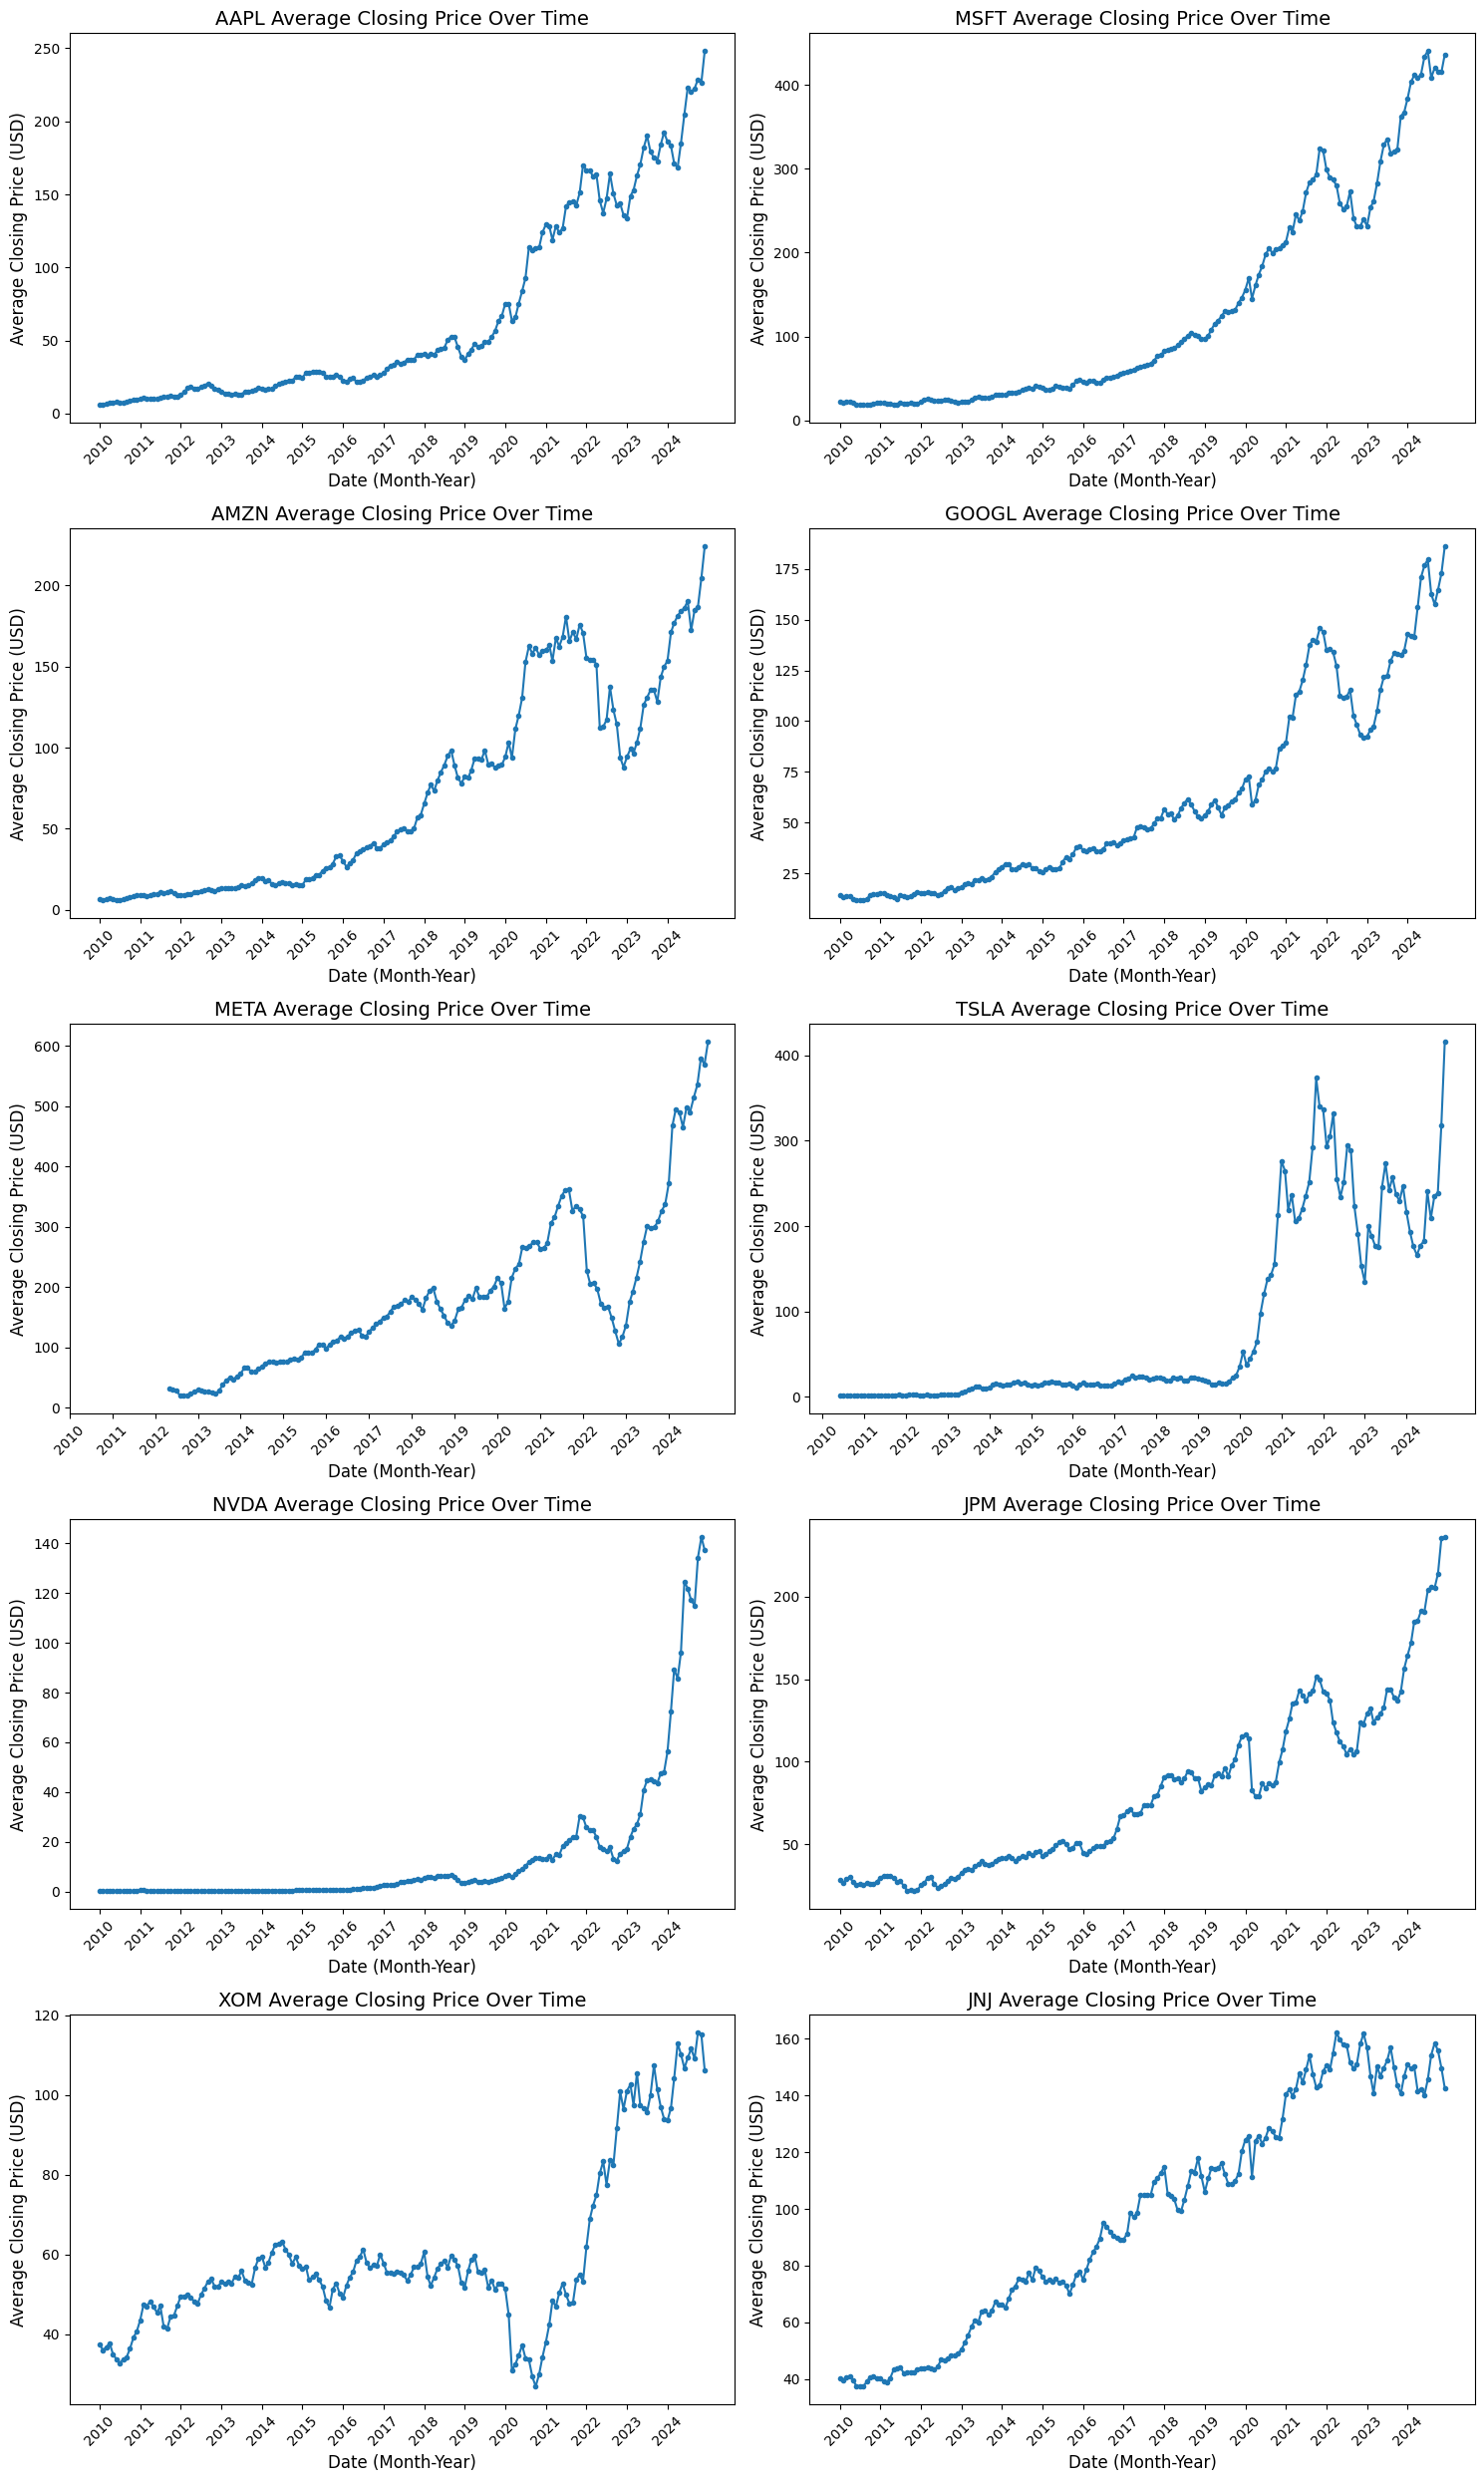

In [ ]:
# TODO: Plot each company ticker
TICKERS = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'TSLA', 'NVDA', 'JPM', 'XOM', 'JNJ']
plt.figure(figsize=(15, 25))

for i, ticker in enumerate(TICKERS):
    ax = plt.subplot(5, 2, i + 1)
    ticker_data = monthly_avg_close[monthly_avg_close['Ticker'] == ticker].copy()

    if 'Plot Date' not in ticker_data.columns:
        ticker_data['Plot Date'] = pd.to_datetime(ticker_data[['Year', 'Month']].assign(day=1))

    ax.plot(ticker_data['Plot Date'], ticker_data['Monthly Avg Close'], marker='.', linestyle='-')

    years_to_label = ticker_data['Year'].unique()

    tick_dates = pd.to_datetime(years_to_label, format='%Y').tolist()

    ax.set_xticks(tick_dates)

    ax.set_xticklabels(years_to_label, rotation=45)

    ax.set_title(f'{ticker} Average Closing Price Over Time', fontsize=14)
    ax.set_xlabel('Date (Month-Year)', fontsize=12)
    ax.set_ylabel('Average Closing Price (USD)', fontsize=12)

    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 4.1.3: Moving Average Model

Now that we have finished our EDA, we will begin fitting models to our data. We will aim to forecast `'AAPL'` stock prices (`'Close'`) from this point onwards - please keep this in mind thoughout the remaining parts.

The first model we will apply to this model is a simple moving average model.


#### 4.1.3.1: Define Moving Average Model Class

**TODO:** In this exercise, you will complete the `MovingAverage` class.

The Moving Average model predicts each value in a series by **averaging the previous q**  observations. If there are fewer than q past values, it averages all available values up to that point. This smooths out short-term fluctuations to reveal longer-term trends.

Complete the constructor below. Your final model should take in $q$, or the number of terms to consider in the moving average. The method `fit_transform` should take in target variable (time-series variable) `x`, and output the predictions returned based on your model architecture.

**Hint 1:** To debug your model, we recommend writing a few test cases as a sanity check.

**Hint 2:** What do you think the moving average model should do when there are not enough examples to average?

**Hint 3:** The expected output size for the fit_transform method is the same as the input.


In [ ]:
import numpy as np

class MovingAverage:
    def __init__(self, q):
        self.q = q

    def fit_transform(self, x):
        x = np.asarray(x, dtype=float)
        n = len(x)
        predictions = []

        for i in range(n):
            start = max(0, i - self.q + 1)
            window = x[start : i + 1]
            predictions.append(window.mean())

        return np.array(predictions)


#### 4.1.3.2: Fit Moving Average Models to Data

**TODO:** The next step is to fit the moving average models to your data. Fit five MA models trying different values of q from the list `[1, 10, 100, 1000, 5000]`, and compute the mean squared error between your moving average models and the actual ground truth data.


In [ ]:
apple_df = df[df["Ticker"] == "AAPL"]
apple_close = apple_df["Close"]

In [ ]:
mse = [] # Store your 5 MSE values in here
actual = apple_close

## TODO: Fit MA models
Q_VALUES = [1, 10, 100, 1000, 5000]
data_array = actual.values
for q in Q_VALUES:
    ma_model = MovingAverage(q)
    predictions = ma_model.fit_transform(data_array)
    error = np.mean((predictions - data_array)**2)
    mse.append(error)

#### 4.1.3.3: Plot Moving Average Models

**TODO:** Finally, plot the predicted stock price over time for each of the five moving average models. Your final graph should have six lines (5 lines for the models and 1 for the actual stock prices)

Remember to include an axis title, labels, and legend in your plot, and to color code each of your models.


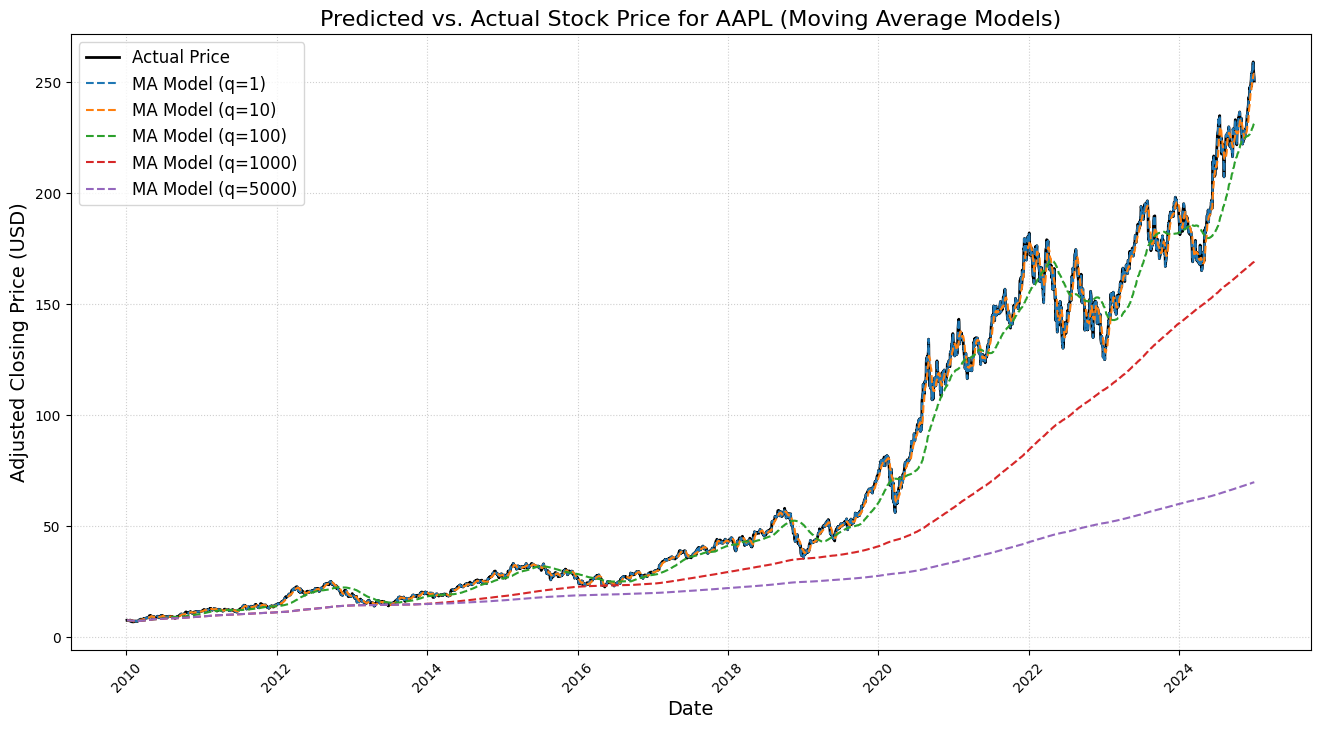

In [ ]:
## TODO: Plot Moving Average Models
Q_VALUES = [1, 10, 100, 1000, 5000]

actual_prices = actual.values
dates = apple_df[apple_df["Ticker"] == "AAPL"]["Date"]

plt.figure(figsize=(16, 8))

plt.plot(dates, actual_prices, label='Actual Price', color='black', linewidth=2, linestyle='-')
for q in Q_VALUES:
    ma_model = MovingAverage(q)
    predictions = ma_model.fit_transform(actual_prices)
    plt.plot(dates, predictions, label=f'MA Model (q={q})', linestyle='--')

plt.title('Predicted vs. Actual Stock Price for AAPL (Moving Average Models)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Adjusted Closing Price (USD)', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)

plt.show()

## 4.2: Time-Series Machine Learning in Python

Previously, we explored some traditional methods of time-series modelling. There are also a few other model types (such as exponential smoothing and Holt's Method), which we will not cover in this exercise. However, in this section, we will seek to apply machine learning methods to fit to our time-series data.


### 4.2.1: Loading our Data in `PyTorch`

**TODOs:**
- Follow the TODOs below to prepare the `X` and `y` features for your model training:
 - Complete the `prepare_data` method to preprocess our data to input into our machine learning methods.
 - Define DataLoaders to feed into our machine learning algorithms using the `prepare_data` method.

**Notes/Hints:**
- Remember - we will only be performing the prediction for the `'AAPL'` ticker.
- If you get stuck, imagine a sliding window of `sequence_length`:
 - `X` should be a tensor where each element is a particular sliding window (elements `i` to `i+sequence_length`) of the close prices. That is, `X` should be a tensor of tensors, each of length `sequence_length`.
 - `y` is a tensor where each element is the singular closing price of the point right after the sliding window of the corresponding `X` (element `sequence_length+i`).
- If you are confused by the idea of a sliding window in this section, remember the context in which we are applying machine learning - at each period of time, we are limiting the machine learning algorithm to only have access to a few previous data points (which are captured by the sliding window). These functions will help us to do this.


In [ ]:
def prepare_data(data, ticker, sequence_length):

    ticker_data = data[data['Ticker'] == ticker].copy()
    X = ticker_data[['Adj Close']].values

    train_size = int(len(X) * 0.8)

    # TODO: create train and test split on X (use 80% for training)
    X_train = X[:train_size]
    X_test = X[train_size:]

    scaler = MinMaxScaler(feature_range=(0, 1))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_new, y_train_new, X_test_new, y_test_new = [], [], [], []

    for i in range(len(X_train_scaled) - sequence_length):
        X_train_new.append(X_train_scaled[i : i + sequence_length, 0])
        y_train_new.append(X_train_scaled[i + sequence_length, 0])

    for i in range(len(X_test_scaled) - sequence_length):
        X_test_new.append(X_test_scaled[i : i + sequence_length, 0])
        y_test_new.append(X_test_scaled[i + sequence_length, 0])


    X_train_final = np.array(X_train_new)
    y_train_final = np.array(y_train_new)
    X_test_final = np.array(X_test_new)
    y_test_final = np.array(y_test_new)

    return torch.tensor(X_train_final, dtype=torch.float32).unsqueeze(-1), \
           torch.tensor(y_train_final, dtype=torch.float32).unsqueeze(-1), \
           torch.tensor(X_test_final, dtype=torch.float32).unsqueeze(-1), \
           torch.tensor(y_test_final, dtype=torch.float32).unsqueeze(-1), \
           scaler

In [ ]:
# DO NOT CHANGE
# Pass data in your prepare_data function
sequence_length = 500
ticker = 'AAPL'
X_train, y_train, X_test, y_test, scaler = prepare_data(df, ticker, sequence_length)


**TODO:** Create DataLoaders for training and testing sets. Use a batch size of 32 and set the shuffle argument to False.


In [ ]:
# TODO: Create DataLoaders
batch_size = 32

train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

### 4.2.2: Recurrent Neural Network (RNN)

RNNs are neural networks trained on sequential data (ex: time series data or sequence of words). It is great at capturing temporal relationships. Using the past sequence, it can predict future values, making it a suitable model for forecasting.

Below, we have an example of an RNN architecture. It has multiple hidden layers, as well as an output layer.
Unlike a FCN, an RNN model shares the parameters across different layers. This allows the weights (U) to learn the data in a sequential way by remembering data from previous steps.

At each step, an output y is generated. During backpropagation, this model will calculate the loss of the predicted output at each time step versus the actual output.


#### 4.2.2.1: Define RNN Architecture in `PyTorch`
**TODOs:** Now, you will implement this RNN architecture in `PyTorch`.
- Follow the TODOs below and define an RNN model class.
- You may also refer to the `PyTorch` documentation for guidance.


In [ ]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.input_size = input_size
        # TODO: Define stacked RNN layers (see nn.RNN)
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        # TODO: Define a fully connected layer
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x, hidden=None):
        # TODO: Initialize hidden state of zeros if it doesn't exist
        if hidden is None:
            batch_size = x.size(0)
            hidden = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        # TODO: Pass x and the hidden state through RNN layer
        out, hidden = self.rnn(x, hidden)
        # TODO: Pass the last output of the sequence to the fully connected layer
        out = self.fc(out[:, -1, :])
        return out, hidden


In [ ]:
# TODO: come up with relevant hyperparameters
input_size = 1 # HINT: Using 'Close' only
hidden_size = 64
output_size = 1
num_layers = 2

model = RNN(input_size, hidden_size, output_size, num_layers)

#### 4.2.2.2: Fit/train RNN Model

Excellent - now that the RNN model has been defined, let's train it on our model.

**TODO:** Complete the `train_model` function, which defines a training loop for us to use in the subsequent parts.

**Hints:**
* If you are still confused on training loops, we encourage you to refer to your code for the HW 5 main path. Note that even though we have changed the model architecture from an FCN/CNN to an RNN, `Pytorch` provides the same framework for training all of these algorithms, so we can use a very similarly-structured training loop.
* You will need to decide on appropriate parameters for the model. If you are getting a very poor loss value/losing points on the autograder, consider changing your model parameters.


In [ ]:
# set seed
torch.manual_seed(42)

In [ ]:
def train_model(model, train_loader, criterion, optimizer, epochs=20):
    '''
    Inputs:
    - model: instantiated machine learning model to be trained
    - train_loader: DataLoader object containing training data for the model
    - criterion: loss criterion on which to train the model on
    - optimizer: PyTorch optimizer object
    - epochs: number of epochs
    '''
    loss_list = []
    model = model.to(device)
    criterion = criterion.to(device)
    model.train()

    # TODO: Implement the training loop
    for epoch in range(epochs):
        total_epoch_loss = 0
        num_batches = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs, _ = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_epoch_loss += loss.item()
            num_batches += 1

        # Calculate and print the average loss for the epoch
        avg_epoch_loss = total_epoch_loss / num_batches

        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_epoch_loss:.4f}")
        loss_list.append(avg_epoch_loss)

    return loss_list

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)-

loss_list = train_model(model, train_loader, criterion, optimizer)


Epoch 1/20, Loss: 0.0080
Epoch 2/20, Loss: 0.0812
Epoch 3/20, Loss: 0.0412
Epoch 4/20, Loss: 0.0252
Epoch 5/20, Loss: 0.0127
Epoch 6/20, Loss: 0.0040
Epoch 7/20, Loss: 0.0003
Epoch 8/20, Loss: 0.0006
Epoch 9/20, Loss: 0.0003
Epoch 10/20, Loss: 0.0005
Epoch 11/20, Loss: 0.0004
Epoch 12/20, Loss: 0.0004
Epoch 13/20, Loss: 0.0004
Epoch 14/20, Loss: 0.0004
Epoch 15/20, Loss: 0.0004
Epoch 16/20, Loss: 0.0005
Epoch 17/20, Loss: 0.0005
Epoch 18/20, Loss: 0.0005
Epoch 19/20, Loss: 0.0005
Epoch 20/20, Loss: 0.0005


NOTE: Your loss values may seem low. This is because in the data prep section, we scaled all the values from 0 to 1, which yields a small loss (even though there may be errors)


#### 4.2.2.3: Evaluate RNN Model

**TODO:** Finally, we will evaluate the RNN model on the test data.
- Complete the below `evaluate_model` method to evaluate your model on the test data.
- Complete the `plot_predictions_over_time` function to generate a plot of the predicted values. The function should plot both the ground truth values and the model prediction on the same pair of axes. Remember to include a figure title, axis titles, and legend in your function.

In [ ]:
def evaluate_model(model, test_loader, scaler):
    '''
    Inputs:
    - model: the (trained) model to be tested
    - test_loader: DataLoader containing test dataset
    - scaler - fitted MinMaxScaler to the close prices (used for inverse transforming results)
    '''
    model = model.to(device)
    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:

            # TODO: move data to device and get predictions
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs, _ = model(X_batch)

            # Move data back to CPU and convert to NumPy
            y_hat = outputs.cpu().numpy()
            y_true = y_batch.cpu().numpy()

            # Inverse transform the scaled predictions and actuals
            y_hat_rescaled = scaler.inverse_transform(y_hat)
            y_true_rescaled = scaler.inverse_transform(y_true)

            # TODO: move data back to CPU and append to lists
            predictions.extend(y_hat_rescaled.flatten())
            actuals.extend(y_true_rescaled.flatten())

    return np.array(predictions), np.array(actuals)


In [ ]:
def plot_predictions_over_time(predictions, actuals, title = 'RNN Model Prediction vs. Actual Stock Price'):
    '''
    Plot predictions vs actuals over time
    '''

    plt.figure(figsize=(14, 7))
    plt.plot(actuals, label='Actual Price', color='blue', linewidth=2)

    plt.plot(predictions, label='Predicted Price', color='red', linestyle='--')

    plt.title(title, fontsize=16)
    plt.xlabel('Time Steps in Test Set', fontsize=14)
    plt.ylabel('Adjusted Closing Price (USD)', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.show()


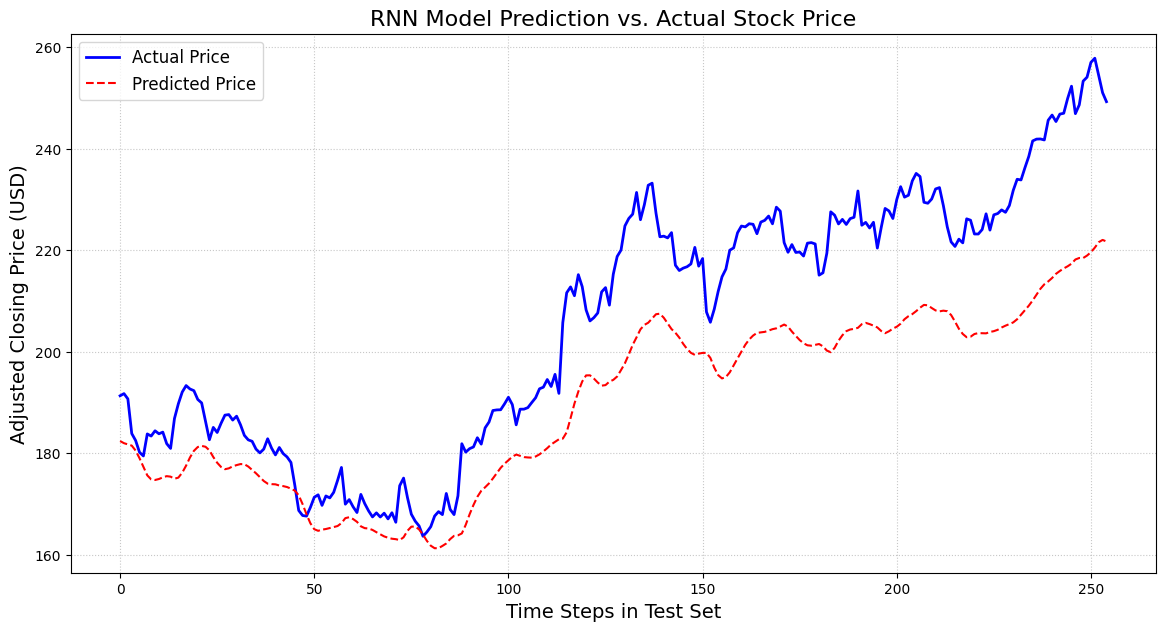

In [ ]:
# Evaluate and plot
predictions, actuals = evaluate_model(model, test_loader, scaler)
plot_predictions_over_time(predictions, actuals)


### 4.2.3: Long-Short Term Memory (LSTM) Model

LSTMs are a special kind of RNN capable of learning long-term dependencies. They were designed to avoid the long-term dependency problem that standard RNNs face.

LSTMs have a similar chain-like structure to RNNs, but the repeating module has a different structure. Instead of having a single neural network layer, there are four interacting layers communicating in a special way.


#### 4.2.3.1: Define LSTM Architecture

**TODO:** Following a similar pattern to the RNN implementation, define an LSTM model.
- Use `nn.LSTM` instead of `nn.RNN`
- The rest of the structure should be very similar


In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # TODO: Define LSTM layers (see nn.LSTM)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # TODO: Define fully connected layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden=None):
        batch_size = x.size(0)

        if hidden is None:
            h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
            c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
            hidden = (h0, c0)

        out, (hidden, cell) = self.lstm(x, hidden)
        last_out = out[:, -1, :]
        out = self.fc(last_out)
        return out, (hidden, cell)

# TODO: Initialize LSTM model with appropriate hyperparameters
input_size = 1
hidden_size = 128
output_size = 1
num_layers = 3
lstm_model = LSTM(input_size, hidden_size, output_size, num_layers)

#### 4.2.3.2: Train LSTM Model

**TODO:** Train the LSTM model using the same training function as before.


In [ ]:
# set seed
torch.manual_seed(42)
# TODO: Train LSTM model
lstm_model = LSTM(input_size, hidden_size, output_size, num_layers)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-4)
lstm_loss_list = []
lstm_loss_list = train_model(lstm_model, train_loader, criterion, optimizer)

Epoch 1/20, Loss: 0.0112
Epoch 2/20, Loss: 0.1077
Epoch 3/20, Loss: 0.0549
Epoch 4/20, Loss: 0.0548
Epoch 5/20, Loss: 0.0539
Epoch 6/20, Loss: 0.0517
Epoch 7/20, Loss: 0.0449
Epoch 8/20, Loss: 0.0202
Epoch 9/20, Loss: 0.0078
Epoch 10/20, Loss: 0.0041
Epoch 11/20, Loss: 0.0032
Epoch 12/20, Loss: 0.0027
Epoch 13/20, Loss: 0.0023
Epoch 14/20, Loss: 0.0018
Epoch 15/20, Loss: 0.0014
Epoch 16/20, Loss: 0.0013
Epoch 17/20, Loss: 0.0015
Epoch 18/20, Loss: 0.0018
Epoch 19/20, Loss: 0.0020
Epoch 20/20, Loss: 0.0020


#### 4.2.3.3: Evaluate LSTM Model

**TODO:** Evaluate the LSTM model and plot the results. Y axis should be the stock price and X axis should be the time index. Remember to have axis titles


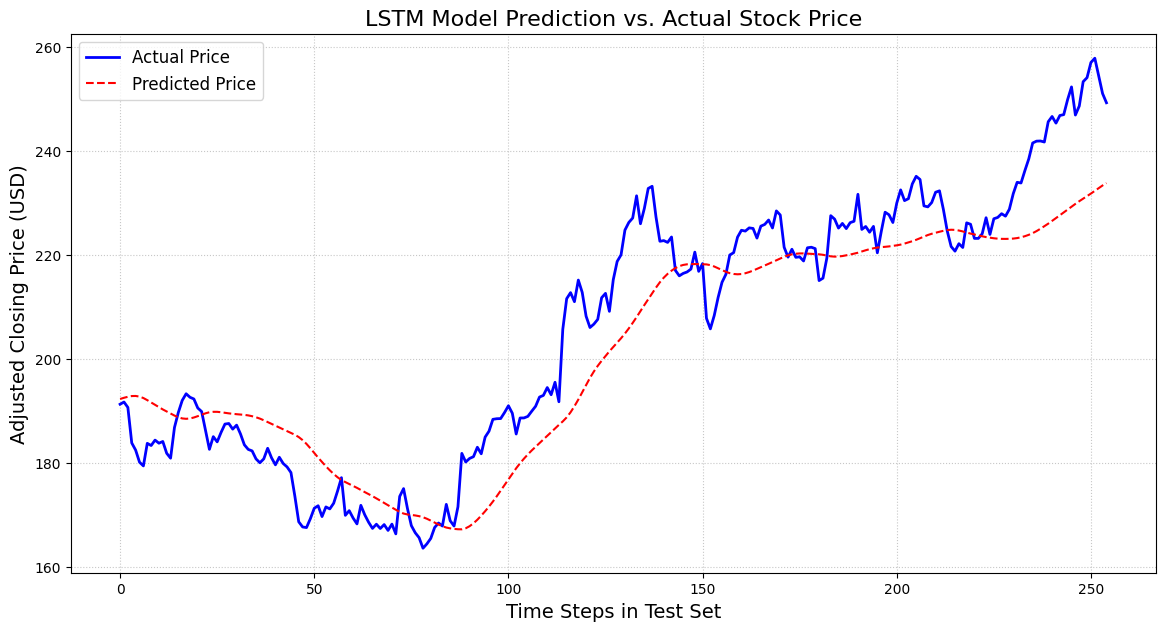

In [ ]:
# TODO: Evaluate and plot LSTM results
predictions, actuals = evaluate_model(lstm_model, test_loader, scaler)
plot_predictions_over_time(predictions, actuals, title = 'LSTM Model Prediction vs. Actual Stock Price')

### 4.2.4: Reflection

**TODO:** In 3-5 sentences, compare and contrast the RNN and LSTM models. Which performed better? Why do you think that is? What are the trade-offs between the two models?


 **For the RNN and LSTM models, the LSTM clearly performs better. Although the RNN has a lower final loss value (around 0.0005) compared to the LSTM (around 0.0020), the plot shows that the RNN’s predicted curve consistently displays significant lag and deviation from the true price. This deviation indicates that the RNN model is unable to effectively capture long-sequence dependencies. In contrast, the LSTM’s predictions follow the actual price movements much more closely, demonstrating that it has learned the temporal patterns in the data more accurately. The LSTM’s superior performance comes from its unique cell state and gating mechanisms, which allow it to overcome the vanishing gradient problem that affects simple RNNs. This means the LSTM can retain important information across long sequences, enabling more precise predictions. The main trade-off is that the LSTM is more computationally expensive, but for complex time series tasks that require long-term memory, this extra cost is worthwhile.**
